# Output Visual dan Tabel BAB 4

Notebook ini membuat artefak tabel dan visual untuk BAB 4 berdasarkan `TODO_BAB_4_Lengkap.md`.
Struktur mengikuti sub-subbab agar output wajib, sangat disarankan, disarankan, dan opsional tidak tercampur.


## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran. Jika artefak belum tersedia, notebook membuat tabel status/warning dan tetap lanjut.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.1.1 Statistik Preprocessing dan Contoh Channel

Membuat statistik fitur VV, VH, HSV, Slope, HAND dari tile `.npz`, tabel validitas Sentinel-2, dan contoh visual channel dari wilayah uji.


In [3]:
rows = []
for region in REGIONS:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    files = sorted(tile_dir.glob("*.npz"))
    if not files:
        rows.append({"region": region, "status": "missing_tiles"})
        continue
    sample_files = files[::max(1, len(files)//25)][:25]
    channel_values = defaultdict(list)
    valid_pixels = 0
    s2_valid_pixels = 0
    total_pixels = 0
    for path in sample_files:
        z = load_npz(path)
        x = np.asarray(z["x"])
        valid = np.asarray(z.get("feature_valid_mask", z.get("valid_mask", np.ones((1, x.shape[-2], x.shape[-1])))))[0] > 0
        s2_valid = np.asarray(z.get("s2_valid_mask", np.zeros((1, x.shape[-2], x.shape[-1]))))[0] > 0
        total_pixels += valid.size
        valid_pixels += int(valid.sum())
        s2_valid_pixels += int((s2_valid & valid).sum())
        for idx, channel in enumerate(CHANNEL_NAMES):
            vals = x[idx][valid]
            if vals.size:
                channel_values[channel].append(vals[::max(1, vals.size//5000)])
    base = {
        "region": region,
        "sample_tiles": len(sample_files),
        "feature_valid_pct": pct(valid_pixels, total_pixels),
        "s2_valid_pct": pct(s2_valid_pixels, valid_pixels),
        "status": "ok",
    }
    for channel in CHANNEL_NAMES:
        vals = np.concatenate(channel_values[channel]) if channel_values[channel] else np.array([])
        stats = finite_stats(vals)
        rows.append({**base, "channel": channel, **{k: stats[k] for k in ["count", "min", "max", "mean", "std", "p2", "p98"]}})

preprocessing_stats = pd.DataFrame(rows)
save_table(preprocessing_stats, "4_1_1_preprocessing_stats.csv")


saved table: outputs/bab4/tables/4_1_1_preprocessing_stats.csv (77 rows)


,region,sample_tiles,feature_valid_pct,s2_valid_pct,status,channel,count,min,max,mean,std,p2,p98
0,Aceh_Besar,25,90.0439,75.4905,ok,vv_norm,121320,0.0,1.000000,0.716490,0.137341,0.390268,1.000000
1,Aceh_Besar,25,90.0439,75.4905,ok,vh_norm,121320,0.0,1.000000,0.499151,0.142457,0.145164,0.783035
2,Aceh_Besar,25,90.0439,75.4905,ok,hue,121320,0.0,0.997416,0.231985,0.145776,0.000000,0.490283
3,Aceh_Besar,25,90.0439,75.4905,ok,saturation,121320,0.0,1.000000,0.634747,0.390593,0.000000,0.957708
4,Aceh_Besar,25,90.0439,75.4905,ok,value,121320,0.0,0.954400,0.245463,0.168868,0.000000,0.509924
5,Aceh_Besar,25,90.0439,75.4905,ok,slope_norm,121320,0.0,1.000000,0.304938,0.228337,0.000000,0.822079
6,Aceh_Besar,25,90.0439,75.4905,ok,hand_norm,121320,0.0,1.000000,0.618252,0.376728,0.006587,1.000000
7,Aceh_Tamiang,25,69.0515,0.0000,ok,vv_norm,91374,0.0,1.000000,0.679493,0.180141,0.169691,0.990521
8,Aceh_Tamiang,25,69.0515,0.0000,ok,vh_norm,91374,0.0,1.000000,0.464744,0.169483,0.000000,0.760804
9,Aceh_Tamiang,25,69.0515,0.0000,ok,hue,91374,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_1_1_preprocessing_stats.csv')

saved table: outputs/bab4/tables/4_1_1_s2_valid_mask_by_region.csv (11 rows)


,region,sample_tiles,feature_valid_pct,s2_valid_pct,status
0,Aceh_Besar,25,90.0439,75.4905,ok
7,Aceh_Tamiang,25,69.0515,0.0000,ok
14,Aceh_Timur,25,74.1400,49.8045,ok
21,Aceh_Utara,25,76.8636,79.3477,ok
28,Agam,25,76.1383,0.0000,ok
35,Banda_Aceh,16,56.4618,84.6215,ok
42,Bireuen,25,87.3601,86.9562,ok
49,Langsa,25,73.5044,0.0000,ok
56,Pasaman_Barat,25,86.1479,0.0147,ok
63,Pidie,25,70.2861,94.6102,ok


saved figure: outputs/bab4/figures/4_1_1_s2_valid_mask_by_region.png


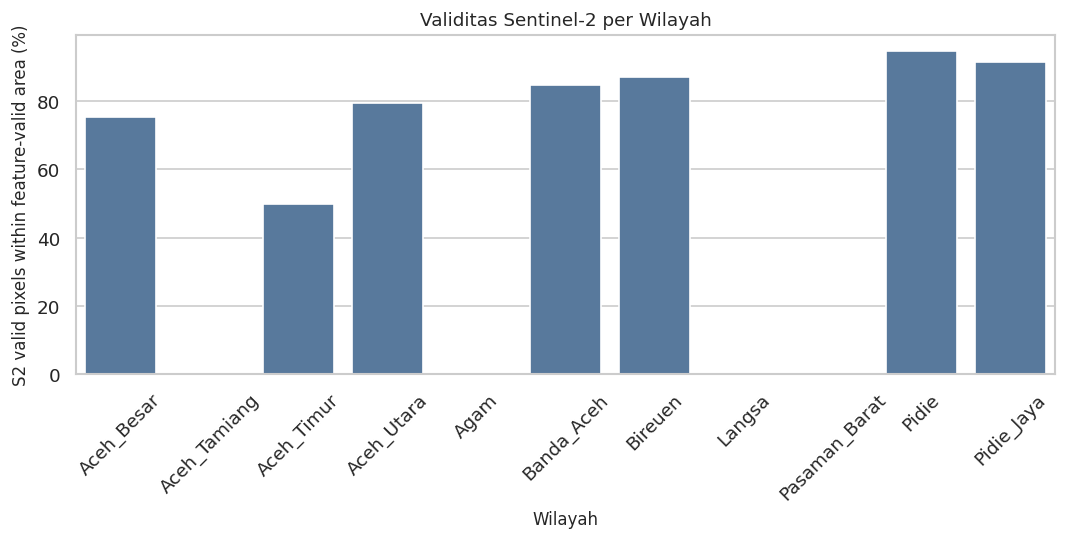

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_1_1_s2_valid_mask_by_region.png')

In [4]:
s2_table = preprocessing_stats[["region", "sample_tiles", "feature_valid_pct", "s2_valid_pct", "status"]].drop_duplicates().sort_values("region")
save_table(s2_table, "4_1_1_s2_valid_mask_by_region.csv")

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = s2_table[s2_table["status"].eq("ok")]
if not plot_df.empty:
    sns.barplot(data=plot_df, x="region", y="s2_valid_pct", ax=ax, color="#4C78A8")
    ax.set_ylabel("S2 valid pixels within feature-valid area (%)")
    ax.set_xlabel("Wilayah")
    ax.tick_params(axis="x", rotation=45)
    ax.set_title("Validitas Sentinel-2 per Wilayah")
else:
    ax.text(0.5, 0.5, "No S2 valid-mask data", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_1_1_s2_valid_mask_by_region.png")


saved figure: outputs/bab4/figures/4_1_1_channel_example_aceh_utara.png


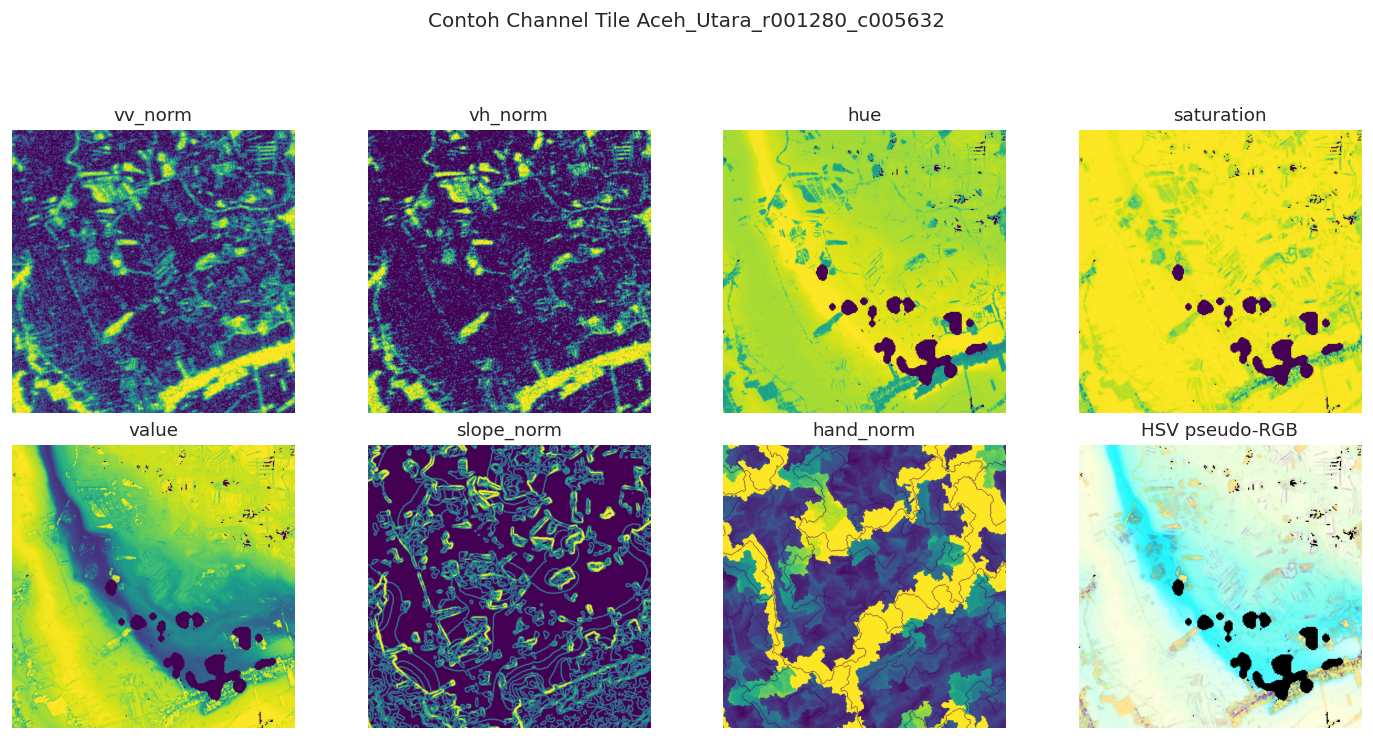

In [5]:
tile_path = choose_tile(TEST_REGION)
if tile_path is None:
    status = pd.DataFrame([{"region": TEST_REGION, "status": "missing_tile", "note": "No tile available for channel example"}])
    save_table(status, "4_1_1_channel_example_status.csv")
else:
    z = load_npz(tile_path)
    x = np.asarray(z["x"])
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for idx, channel in enumerate(CHANNEL_NAMES):
        axes[idx].imshow(normalize_image(x[idx]), cmap="viridis")
        axes[idx].set_title(channel)
        axes[idx].axis("off")
    pseudo_rgb = np.dstack([normalize_image(x[4]), normalize_image(x[3]), normalize_image(x[2])])
    axes[7].imshow(pseudo_rgb)
    axes[7].set_title("HSV pseudo-RGB")
    axes[7].axis("off")
    fig.suptitle(f"Contoh Channel Tile {tile_path.stem}", y=1.02)
    save_fig(fig, "4_1_1_channel_example_aceh_utara.png")


## 4.1.2 Verifikasi Alignment Raster Multisensor

Menyajikan laporan alignment dari hasil verifikasi preprocessing. Jika `rasterio` tersedia, notebook juga dapat menghitung metadata raster tambahan.


In [6]:
alignment = read_csv_or_status(DATASET / "preprocessing_verification_report.csv", "preprocessing verification report")
save_table(alignment, "4_1_2_alignment_verification.csv")

raster_meta_rows = []
for region in REGIONS:
    feature_dir = DATASET / "features_preprocessed" / region
    for filename in ["vv_norm.tif", "vh_norm.tif", "hue.tif", "saturation.tif", "value.tif", "slope_norm.tif", "hand_meters.tif", "s2_valid_mask.tif"]:
        path = feature_dir / filename
        stats = raster_stats(path, sample_step=50)
        raster_meta_rows.append({"region": region, "raster": filename, "path": str(path.relative_to(ROOT)), **stats})
raster_meta = pd.DataFrame(raster_meta_rows)
save_table(raster_meta, "4_1_2_raster_metadata_optional.csv")


saved table: outputs/bab4/tables/4_1_2_alignment_verification.csv (11 rows)


,region,stack_min,stack_max
0,Aceh_Besar,0.0,1.0
1,Aceh_Tamiang,0.0,1.0
2,Aceh_Timur,0.0,1.0
3,Aceh_Utara,0.0,1.0
4,Agam,0.0,1.0
5,Banda_Aceh,0.0,1.0
6,Bireuen,0.0,1.0
7,Langsa,0.0,1.0
8,Pasaman_Barat,0.0,1.0
9,Pidie,0.0,1.0


saved table: outputs/bab4/tables/4_1_2_raster_metadata_optional.csv (88 rows)


,region,raster,path,count,valid_pct,min,max,mean,std,p2,p98,status,height,width,crs,transform
0,Aceh_Besar,vv_norm.tif,dataset/features_preprocessed/Aceh_Besar/vv_no...,31816,100.0000,0.0,1.000000,0.265403,0.360496,0.0,0.971614,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
1,Aceh_Besar,vh_norm.tif,dataset/features_preprocessed/Aceh_Besar/vh_no...,31816,100.0000,0.0,1.000000,0.186691,0.261860,0.0,0.733747,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
2,Aceh_Besar,hue.tif,dataset/features_preprocessed/Aceh_Besar/hue.tif,31816,100.0000,0.0,0.996372,0.086683,0.141362,0.0,0.331457,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
3,Aceh_Besar,saturation.tif,dataset/features_preprocessed/Aceh_Besar/satur...,31816,100.0000,0.0,1.000000,0.242568,0.393087,0.0,0.952980,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
4,Aceh_Besar,value.tif,dataset/features_preprocessed/Aceh_Besar/value...,31816,100.0000,0.0,0.832000,0.094850,0.160172,0.0,0.466340,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
5,Aceh_Besar,slope_norm.tif,dataset/features_preprocessed/Aceh_Besar/slope...,31816,100.0000,0.0,1.000000,0.109682,0.200042,0.0,0.720603,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
6,Aceh_Besar,hand_meters.tif,dataset/features_preprocessed/Aceh_Besar/hand_...,11342,35.6487,0.0,995.608978,64.119933,93.916113,0.0,332.807287,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
7,Aceh_Besar,s2_valid_mask.tif,dataset/features_preprocessed/Aceh_Besar/s2_va...,31816,100.0000,0.0,1.000000,0.282122,0.450033,0.0,1.000000,ok,8175,9662,EPSG:32646,"| 10.00, 0.00, 718350.00|\n| 0.00,-10.00, 6407..."
8,Aceh_Tamiang,vv_norm.tif,dataset/features_preprocessed/Aceh_Tamiang/vv_...,17625,100.0000,0.0,1.000000,0.343985,0.366024,0.0,0.924822,ok,7013,6210,EPSG:32647,"| 10.00, 0.00, 358850.00|\n| 0.00,-10.00, 5000..."
9,Aceh_Tamiang,vh_norm.tif,dataset/features_preprocessed/Aceh_Tamiang/vh_...,17625,100.0000,0.0,0.973149,0.237316,0.263891,0.0,0.710571,ok,7013,6210,EPSG:32647,"| 10.00, 0.00, 358850.00|\n| 0.00,-10.00, 5000..."


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_1_2_raster_metadata_optional.csv')

## 4.2 Hasil Pembentukan Label UNOSAT dan Dataset Tile

Menghitung statistik label banjir, valid mask, water/river mask, class imbalance, dan distribusi tile.


saved table: outputs/bab4/tables/4_2_label_mask_tile_stats.csv (11 rows)


,region,tiles,pixels_total,valid_pixels,flood_pixels,non_flood_pixels,water_river_pixels,valid_pct,flood_pct_of_valid,water_river_pct_of_valid,s2_valid_pct_of_valid,class_imbalance_non_flood_to_flood,status
0,Aceh_Besar,518,135790592,106956513,4966404,101990109,2607154,78.7658,4.6434,2.4376,80.5364,20.5360,ok
1,Aceh_Tamiang,465,121896960,82307919,3514376,78793543,4407206,67.5225,4.2698,5.3545,0.0008,22.4204,ok
2,Aceh_Timur,1063,278659072,206802875,11748572,195054303,9510741,74.2136,5.6810,4.5989,53.8605,16.6024,ok
3,Aceh_Utara,493,129236992,102158650,18781032,83377618,12835738,79.0475,18.3842,12.5645,79.5878,4.4395,ok
4,Agam,278,72876032,54576695,1054938,53521757,0,74.8898,1.9329,0.0000,0.0000,50.7345,ok
5,Banda_Aceh,16,4194304,2532433,153775,2378658,75817,60.3779,6.0722,2.9938,83.8523,15.4684,ok
6,Bireuen,303,79429632,67149979,3740370,63409609,2439065,84.5402,5.5702,3.6323,87.9336,16.9528,ok
7,Langsa,41,10747904,7395290,471267,6924023,740496,68.8068,6.3725,10.0131,0.0000,14.6924,ok
8,Pasaman_Barat,522,136839168,115359798,1304882,114054916,0,84.3032,1.1311,0.0000,0.0022,87.4063,ok
9,Pidie,572,149946368,110864777,6514184,104350593,3026288,73.9363,5.8758,2.7297,95.8625,16.0190,ok


saved figure: outputs/bab4/figures/4_2_flood_label_distribution.png


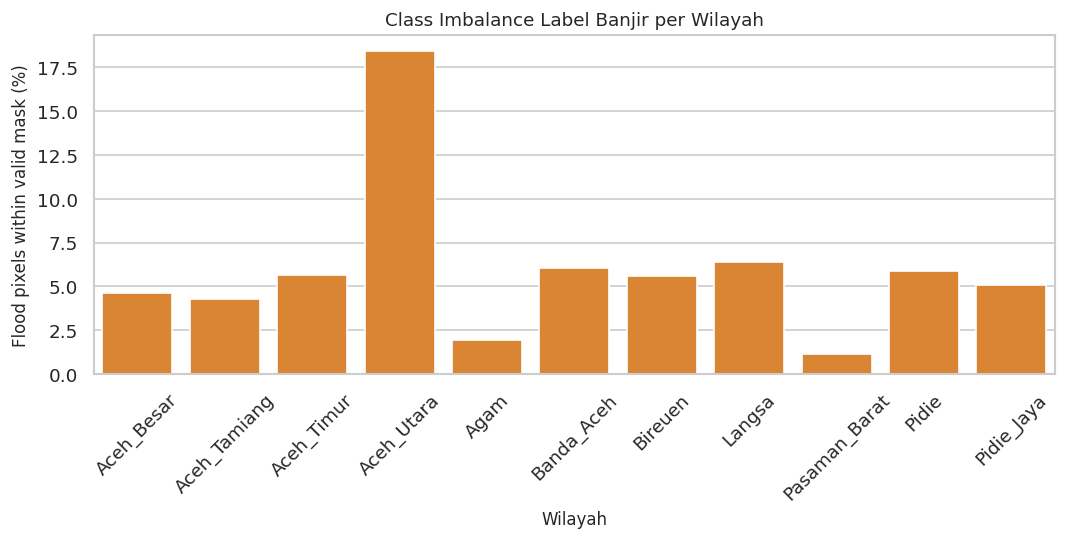

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_2_flood_label_distribution.png')

In [7]:
label_rows = []
for region in REGIONS:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    files = sorted(tile_dir.glob("*.npz"))
    total = valid = flood = water = s2_valid = 0
    for path in files:
        z = load_npz(path)
        y = np.asarray(z["y"])[0] > 0
        valid_mask = np.asarray(z.get("valid_mask", np.ones_like(y)[None]))[0] > 0
        water_mask = np.asarray(z.get("water_river_mask", np.zeros_like(y)[None]))[0] > 0
        s2_mask = np.asarray(z.get("s2_valid_mask", np.zeros_like(y)[None]))[0] > 0
        total += y.size
        valid += int(valid_mask.sum())
        flood += int((y & valid_mask).sum())
        water += int((water_mask & valid_mask).sum())
        s2_valid += int((s2_mask & valid_mask).sum())
    label_rows.append({
        "region": region,
        "tiles": len(files),
        "pixels_total": total,
        "valid_pixels": valid,
        "flood_pixels": flood,
        "non_flood_pixels": max(valid - flood, 0),
        "water_river_pixels": water,
        "valid_pct": pct(valid, total),
        "flood_pct_of_valid": pct(flood, valid),
        "water_river_pct_of_valid": pct(water, valid),
        "s2_valid_pct_of_valid": pct(s2_valid, valid),
        "class_imbalance_non_flood_to_flood": round(safe_div(max(valid - flood, 0), flood), 4) if flood else np.inf,
        "status": "ok" if files else "missing_tiles",
    })
label_stats = pd.DataFrame(label_rows)
save_table(label_stats, "4_2_label_mask_tile_stats.csv")

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = label_stats[label_stats["status"].eq("ok")]
if not plot_df.empty:
    sns.barplot(data=plot_df, x="region", y="flood_pct_of_valid", ax=ax, color="#F58518")
    ax.set_ylabel("Flood pixels within valid mask (%)")
    ax.set_xlabel("Wilayah")
    ax.tick_params(axis="x", rotation=45)
    ax.set_title("Class Imbalance Label Banjir per Wilayah")
else:
    ax.text(0.5, 0.5, "No label data", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_2_flood_label_distribution.png")


In [8]:
tile_rows = []

def region_from_tile_name(path: Path) -> str:
    stem = path.stem
    for region in sorted(REGIONS, key=len, reverse=True):
        if stem.startswith(region + "_"):
            return region
    return stem.split("_r", 1)[0]

for family in ["7ch", "procanet"]:
    family_dir = DATASET / "tiles" / family
    for split in ["train", "val", "test"]:
        split_path = family_dir / split
        if not split_path.exists():
            continue
        counts = Counter()
        nested_files = sorted(split_path.glob("*/*.npz"))
        flat_files = sorted(split_path.glob("*.npz"))
        if nested_files:
            for path in nested_files:
                counts[path.parent.name] += 1
        for path in flat_files:
            counts[region_from_tile_name(path)] += 1
        for region, count in sorted(counts.items()):
            tile_rows.append({"tile_family": family, "split": split, "region": region, "tile_count": count})

    by_region_dir = family_dir / "by_region"
    for region_dir in sorted(by_region_dir.glob("*")):
        if region_dir.is_dir():
            tile_rows.append({"tile_family": family, "split": "by_region", "region": region_dir.name, "tile_count": len(list(region_dir.glob("*.npz")))})

tile_distribution = pd.DataFrame(tile_rows, columns=["tile_family", "split", "region", "tile_count"])
if not tile_distribution.empty:
    tile_distribution = tile_distribution.sort_values(["tile_family", "split", "region"])
save_table(tile_distribution, "4_2_tile_distribution_by_split_region.csv")


saved table: outputs/bab4/tables/4_2_tile_distribution_by_split_region.csv (44 rows)


,tile_family,split,region,tile_count
11,7ch,by_region,Aceh_Besar,518
12,7ch,by_region,Aceh_Tamiang,465
13,7ch,by_region,Aceh_Timur,1063
14,7ch,by_region,Aceh_Utara,493
15,7ch,by_region,Agam,278
16,7ch,by_region,Banda_Aceh,16
17,7ch,by_region,Bireuen,303
18,7ch,by_region,Langsa,41
19,7ch,by_region,Pasaman_Barat,522
20,7ch,by_region,Pidie,572


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_2_tile_distribution_by_split_region.csv')

## 4.3 Pembagian Dataset Spasial dan Validasi Eksperimental

Meringkas split train/val/test dan menandai wilayah uji final.


saved table: outputs/bab4/tables/4_3_preprocessing_summary_source.csv (11 rows)


,region,split,tile_count,positive_tile_count,background_tile_count,flood_pixels,valid_pixels,water_river_pixels,s2_valid_pixels
0,Aceh_Besar,cv,518,315,203,5429056,106956513,3158036,86170341
1,Aceh_Tamiang,cv,465,328,137,4578520,82307919,6063139,672
2,Aceh_Timur,cv,1063,543,520,26605176,206802875,19840072,111438934
3,Aceh_Utara,test,493,332,161,22122708,102158650,15287896,81365271
4,Agam,cv,278,139,139,1257081,54576695,0,0
5,Banda_Aceh,cv,16,16,0,326952,2532433,214485,2130841
6,Bireuen,cv,303,186,117,3827030,67149979,2543747,59076594
7,Langsa,cv,41,37,4,933776,7395290,1289133,0
8,Pasaman_Barat,cv,522,261,261,1462154,115359798,0,2496
9,Pidie,cv,572,286,286,9351866,110864777,4606256,106314945


saved table: outputs/bab4/tables/4_3_feature_preprocessing_summary_source.csv (11 rows)


,region,s2_valid_pct,feature_valid_pct,label_valid_pct,flood_pixels,water_river_pixels
0,Aceh_Besar,28.447850,35.913186,36.648360,1372818,802464
1,Aceh_Tamiang,0.000386,49.680719,50.216387,1143570,1560362
2,Aceh_Timur,28.764821,52.249722,52.784127,6830461,5146283
3,Aceh_Utara,45.582018,56.372950,57.301252,5711905,4054307
4,Agam,0.000000,51.594569,52.035229,332115,0
5,Banda_Aceh,37.536924,42.076136,46.060401,111116,69079
6,Bireuen,55.922736,62.693778,63.241835,1040754,689329
7,Langsa,0.000000,52.017482,53.917292,247096,355790
8,Pasaman_Barat,0.001642,47.087026,47.461440,367204,0
9,Pidie,36.817950,38.326207,38.621073,2345164,1232816


saved table: outputs/bab4/tables/4_3_spatial_split_summary.csv (22 rows)


,tile_family,split,region,tile_count,role
0,7ch,test,Pidie,150,final_test
1,7ch,train,Aceh_Besar,131,training_or_validation
2,7ch,train,Aceh_Tamiang,116,training_or_validation
3,7ch,train,Aceh_Timur,270,training_or_validation
4,7ch,train,Aceh_Utara,127,final_test
5,7ch,train,Agam,96,training_or_validation
6,7ch,train,Banda_Aceh,9,training_or_validation
7,7ch,train,Bireuen,78,training_or_validation
8,7ch,train,Langsa,13,training_or_validation
9,7ch,train,Pasaman_Barat,161,training_or_validation


saved figure: outputs/bab4/figures/4_3_tile_split_distribution.png


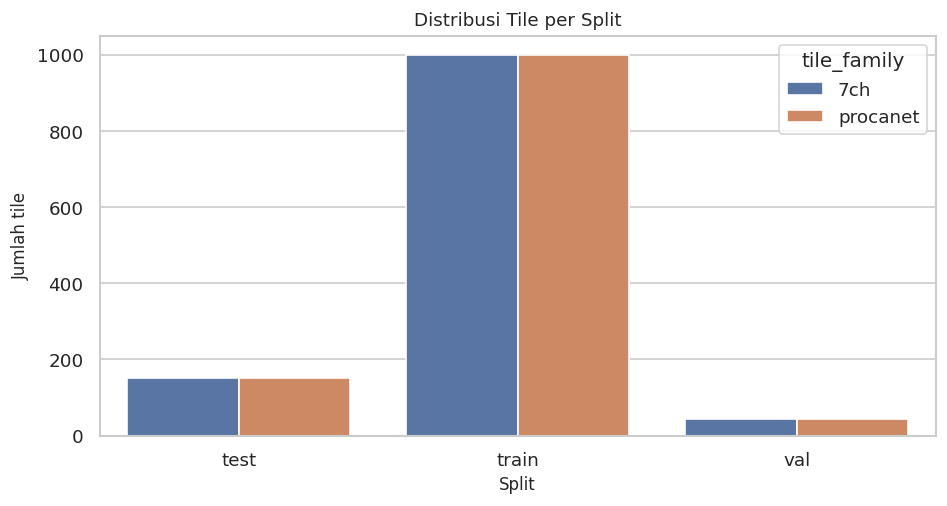

In [9]:
summary = read_csv_or_status(DATASET / "preprocessing_summary.csv", "preprocessing summary")
feature_summary = read_csv_or_status(DATASET / "feature_preprocessing_summary.csv", "feature preprocessing summary")
save_table(summary, "4_3_preprocessing_summary_source.csv")
save_table(feature_summary, "4_3_feature_preprocessing_summary_source.csv")

split_rows = []
if not tile_distribution.empty:
    for _, row in tile_distribution[tile_distribution["split"].isin(["train", "val", "test"])].iterrows():
        split_rows.append({
            "tile_family": row["tile_family"],
            "split": row["split"],
            "region": row["region"],
            "tile_count": row["tile_count"],
            "role": "final_test" if row["region"] == TEST_REGION or row["split"] == "test" else "training_or_validation",
        })
spatial_split = pd.DataFrame(split_rows).sort_values(["tile_family", "split", "region"])
save_table(spatial_split, "4_3_spatial_split_summary.csv")

if not spatial_split.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df = spatial_split.groupby(["tile_family", "split"], as_index=False)["tile_count"].sum()
    sns.barplot(data=plot_df, x="split", y="tile_count", hue="tile_family", ax=ax)
    ax.set_title("Distribusi Tile per Split")
    ax.set_xlabel("Split")
    ax.set_ylabel("Jumlah tile")
    save_fig(fig, "4_3_tile_split_distribution.png")


## 4.4.1 Hasil Implementasi Arsitektur Model

Tabel spesifikasi implementasi aktual U-Net dan ProCANet.


In [10]:
model_specs = pd.DataFrame([
    {
        "model": "U-Net",
        "source_file": "training/models/unet.py",
        "input_tensor": "Batch x 7 x H x W",
        "output_tensor": "Batch x 1 x H x W",
        "core_idea": "Encoder-decoder segmentation baseline dengan skip connection",
        "primary_features": "VV, VH, Hue, Saturation, Value, Slope, HAND",
    },
    {
        "model": "ProCANet",
        "source_file": "training/models/procanet.py",
        "input_tensor": "Encoder1: Batch x 7 x H x W; Encoder2: Batch x 2 x H x W",
        "output_tensor": "Batch x 1 x H x W",
        "core_idea": "Dual encoder dengan cross-attention untuk fusi fitur 7-channel dan SAR VV/VH",
        "primary_features": "Encoder1 multisensor 7 channel; Encoder2 SAR VV/VH",
    },
])
for path_col in ["source_file"]:
    model_specs["source_exists"] = model_specs[path_col].map(lambda p: (ROOT / p).exists())
save_table(model_specs, "4_4_1_model_architecture_specs.csv")


saved table: outputs/bab4/tables/4_4_1_model_architecture_specs.csv (2 rows)


,model,source_file,input_tensor,output_tensor,core_idea,primary_features,source_exists
0,U-Net,training/models/unet.py,Batch x 7 x H x W,Batch x 1 x H x W,Encoder-decoder segmentation baseline dengan s...,"VV, VH, Hue, Saturation, Value, Slope, HAND",True
1,ProCANet,training/models/procanet.py,Encoder1: Batch x 7 x H x W; Encoder2: Batch x...,Batch x 1 x H x W,Dual encoder dengan cross-attention untuk fusi...,Encoder1 multisensor 7 channel; Encoder2 topog...,True


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_1_model_architecture_specs.csv')

## 4.4.2 Hasil Tuning Hyperparameter

Menggabungkan artefak tuning dari `runs/<model>/fold_*/grid_lr_*_wd_*/metrics.csv`.


saved table: outputs/bab4/tables/4_4_2_hyperparameter_tuning_summary.csv (60 rows)


,model,fold,grid,learning_rate,weight_decay,best_metric_column,best_epoch,best_val_iou,best_val_dice,best_val_loss,metrics_path,status
0,procanet,fold_0,grid_lr_1e-4_wd_1e-4,1e-4,1e-4,val_iou,18.0,0.819654,0.900890,0.655554,runs/procanet/fold_0/grid_lr_1e-4_wd_1e-4/metr...,ok
1,procanet,fold_0,grid_lr_1e-4_wd_1e-5,1e-4,1e-5,val_iou,22.0,0.818362,0.900109,0.637633,runs/procanet/fold_0/grid_lr_1e-4_wd_1e-5/metr...,ok
2,procanet,fold_0,grid_lr_1e-5_wd_1e-4,1e-5,1e-4,val_iou,16.0,0.742181,0.852013,0.940960,runs/procanet/fold_0/grid_lr_1e-5_wd_1e-4/metr...,ok
3,procanet,fold_0,grid_lr_1e-5_wd_1e-5,1e-5,1e-5,val_iou,12.0,0.752856,0.859005,0.884496,runs/procanet/fold_0/grid_lr_1e-5_wd_1e-5/metr...,ok
4,procanet,fold_0,grid_lr_5e-5_wd_1e-4,5e-5,1e-4,val_iou,25.0,0.811709,0.896070,0.681458,runs/procanet/fold_0/grid_lr_5e-5_wd_1e-4/metr...,ok
5,procanet,fold_0,grid_lr_5e-5_wd_1e-5,5e-5,1e-5,val_iou,31.0,0.811199,0.895759,0.711292,runs/procanet/fold_0/grid_lr_5e-5_wd_1e-5/metr...,ok
6,procanet,fold_1,grid_lr_1e-4_wd_1e-4,1e-4,1e-4,val_iou,17.0,0.753093,0.859159,0.442656,runs/procanet/fold_1/grid_lr_1e-4_wd_1e-4/metr...,ok
7,procanet,fold_1,grid_lr_1e-4_wd_1e-5,1e-4,1e-5,val_iou,12.0,0.754845,0.860298,0.480218,runs/procanet/fold_1/grid_lr_1e-4_wd_1e-5/metr...,ok
8,procanet,fold_1,grid_lr_1e-5_wd_1e-4,1e-5,1e-4,val_iou,36.0,0.728018,0.842604,0.800585,runs/procanet/fold_1/grid_lr_1e-5_wd_1e-4/metr...,ok
9,procanet,fold_1,grid_lr_1e-5_wd_1e-5,1e-5,1e-5,val_iou,29.0,0.727950,0.842559,0.665736,runs/procanet/fold_1/grid_lr_1e-5_wd_1e-5/metr...,ok


saved figure: outputs/bab4/figures/4_4_2_hyperparameter_heatmap_procanet.png


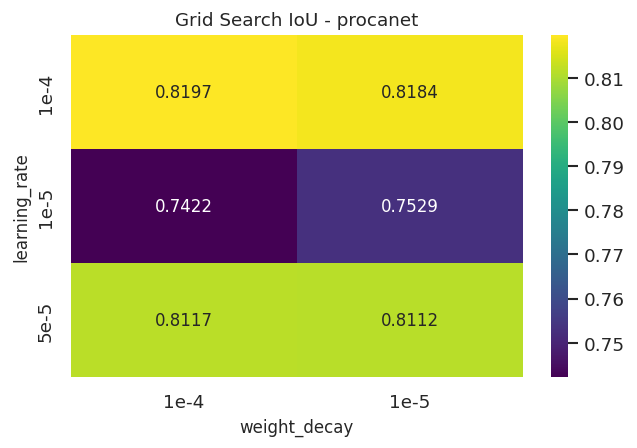

saved figure: outputs/bab4/figures/4_4_2_hyperparameter_heatmap_unet.png


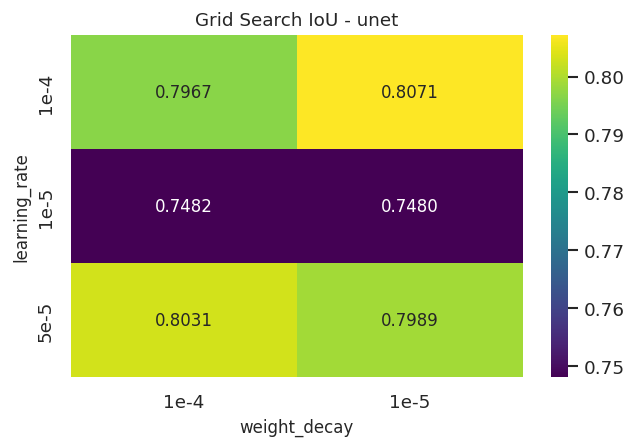

In [11]:
def load_tuning_results() -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(RUNS.glob("*/fold_*/grid_lr_*_wd_*/metrics.csv")):
        parts = metrics_path.parts
        model = metrics_path.relative_to(RUNS).parts[0]
        fold = metrics_path.relative_to(RUNS).parts[1]
        grid = metrics_path.relative_to(RUNS).parts[2]
        df = pd.read_csv(metrics_path)
        if df.empty:
            rows.append({"model": model, "fold": fold, "grid": grid, "status": "empty"})
            continue
        best_col = "val_iou" if "val_iou" in df.columns else ("iou" if "iou" in df.columns else None)
        best_idx = df[best_col].idxmax() if best_col else df.index[-1]
        rec = df.loc[best_idx].to_dict()
        m = re.search(r"lr_([^_]+)_wd_(.+)$", grid)
        rows.append({
            "model": model,
            "fold": fold,
            "grid": grid,
            "learning_rate": m.group(1) if m else "unknown",
            "weight_decay": m.group(2) if m else "unknown",
            "best_metric_column": best_col or "last_row",
            "best_epoch": rec.get("epoch", best_idx),
            "best_val_iou": rec.get("val_iou", rec.get("iou", np.nan)),
            "best_val_dice": rec.get("val_dice", rec.get("dice", np.nan)),
            "best_val_loss": rec.get("val_loss", rec.get("loss", np.nan)),
            "metrics_path": str(metrics_path.relative_to(ROOT)),
            "status": "ok",
        })
    if not rows:
        return pd.DataFrame([{"status": "missing", "note": "No tuning metrics found under runs/*/fold_*/grid_lr_*_wd_*/metrics.csv"}])
    return pd.DataFrame(rows)

tuning = load_tuning_results()
save_table(tuning, "4_4_2_hyperparameter_tuning_summary.csv")

ok_tuning = tuning[tuning.get("status", pd.Series(dtype=str)).eq("ok")] if "status" in tuning else pd.DataFrame()
if not ok_tuning.empty and ok_tuning["best_val_iou"].notna().any():
    for model, g in ok_tuning.groupby("model"):
        pivot = g.pivot_table(index="learning_rate", columns="weight_decay", values="best_val_iou", aggfunc="max")
        fig, ax = plt.subplots(figsize=(5.5, 4))
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax)
        ax.set_title(f"Grid Search IoU - {model}")
        save_fig(fig, f"4_4_2_hyperparameter_heatmap_{model}.png")


## 4.4.3 Stabilitas Pelatihan

Membuat kurva loss, IoU, Dice, dan learning rate dari metrics training yang tersedia.


saved table: outputs/bab4/tables/4_4_3_training_curve_points.csv (1790 rows)


,epoch,train_loss,train_iou,train_dice,train_accuracy,lr,model,run,metrics_path,val_loss,val_iou,val_dice,best_val_iou,saved,bad_epochs,stopped_early
0,1.0,1.065461,0.465841,0.635596,0.967074,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,0.877939,0.611911,0.759237,0.975632,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,0.768815,0.631544,0.774167,0.977400,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,0.676817,0.645312,0.784425,0.978524,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,0.609137,0.652506,0.789717,0.979260,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6.0,0.548237,0.658767,0.794285,0.979889,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7.0,0.504524,0.663375,0.797625,0.980400,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8.0,0.456110,0.674204,0.805402,0.981278,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9.0,0.425354,0.677389,0.807671,0.981585,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10.0,0.406581,0.683490,0.811992,0.982065,0.00010,final,final/procanet,runs/final/procanet/metrics.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN


saved figure: outputs/bab4/figures/4_4_3_training_curves.png


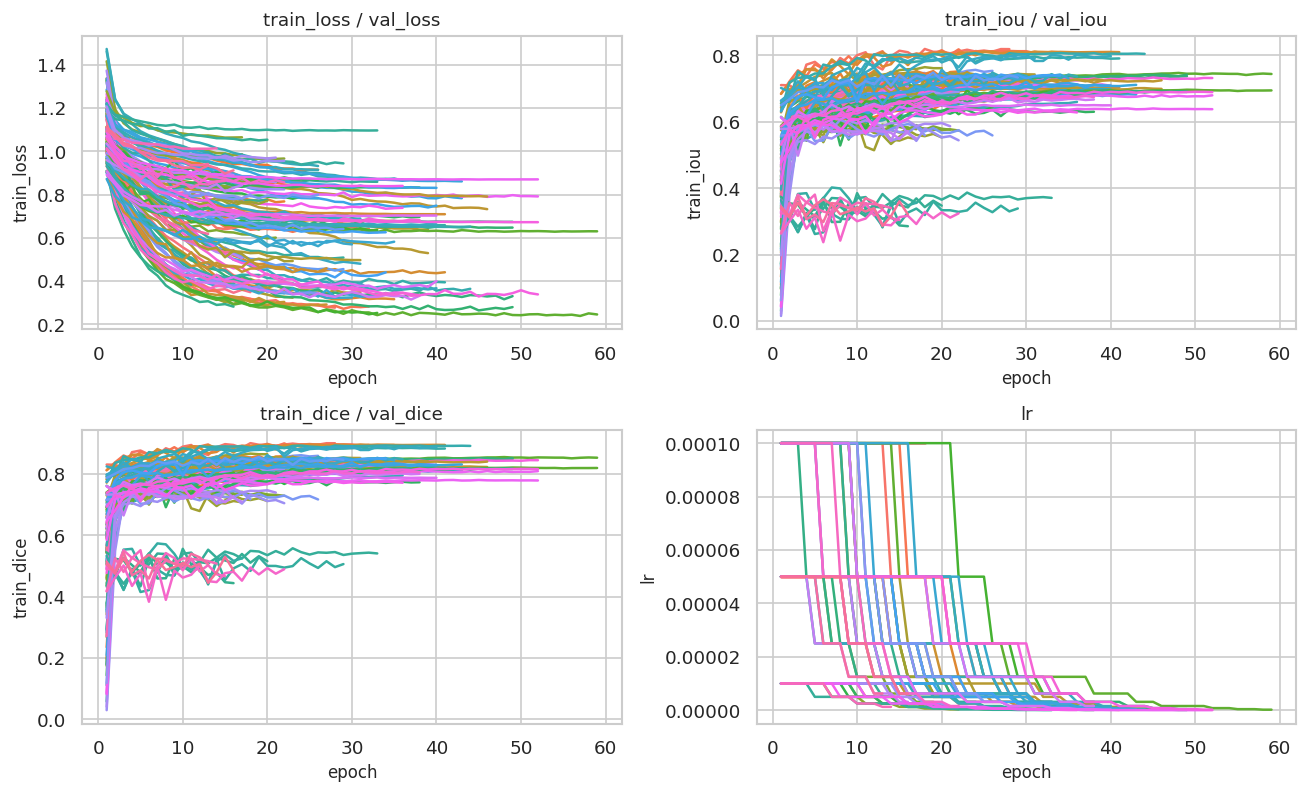

In [12]:
def collect_training_curves() -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(RUNS.glob("**/metrics.csv")):
        rel = metrics_path.relative_to(RUNS)
        if "eval_test" in rel.parts:
            continue
        try:
            df = pd.read_csv(metrics_path)
        except Exception:
            continue
        if df.empty or not any(c in df.columns for c in ["epoch", "train_loss", "val_loss", "loss", "val_iou", "iou", "dice", "val_dice", "lr"]):
            continue
        model = rel.parts[0] if rel.parts else "unknown"
        run_name = "/".join(rel.parts[:-1])
        for _, row in df.iterrows():
            rec = row.to_dict()
            rec.update({"model": model, "run": run_name, "metrics_path": str(metrics_path.relative_to(ROOT))})
            rows.append(rec)
    return pd.DataFrame(rows)

curves = collect_training_curves()
if curves.empty:
    curves = pd.DataFrame([{"status": "missing", "note": "No non-eval training metrics found"}])
save_table(curves, "4_4_3_training_curve_points.csv")

plot_curves = curves.copy()
if "status" not in plot_curves.columns and not plot_curves.empty:
    if "epoch" not in plot_curves.columns:
        plot_curves["epoch"] = plot_curves.groupby("run").cumcount() + 1
    metric_candidates = [("train_loss", "val_loss"), ("train_iou", "val_iou"), ("train_dice", "val_dice"), ("lr", None)]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.ravel()
    for ax, (a, b) in zip(axes, metric_candidates):
        plotted = False
        for col in [a, b]:
            if col and col in plot_curves.columns:
                sns.lineplot(data=plot_curves, x="epoch", y=col, hue="run", ax=ax, legend=False)
                plotted = True
        ax.set_title(" / ".join([c for c in [a, b] if c]))
        if not plotted:
            ax.text(0.5, 0.5, "metric unavailable", ha="center", va="center")
            ax.axis("off")
    save_fig(fig, "4_4_3_training_curves.png")


## 4.5 Evaluasi Akhir pada Wilayah Uji Aceh_Utara

Menyajikan metrik final dan confusion matrix piksel untuk U-Net dan ProCANet.


saved table: outputs/bab4/tables/4_5_final_metrics.csv (2 rows)


,model,region,loss,iou,dice_f1,accuracy,precision,recall,source,status
0,unet,Aceh_Utara,0.604995,0.850992,0.919498,0.970733,NaN,NaN,runs/final/unet/eval_test/metrics.csv,ok
1,procanet,Aceh_Utara,0.628500,0.838298,0.912037,0.968751,NaN,NaN,runs/final/procanet/eval_test/metrics.csv,ok


saved table: outputs/bab4/tables/4_5_confusion_matrix_pixels.csv (2 rows)


,model,region,tp,tn,fp,fn,status
0,unet,Aceh_Utara,16863330,81075762,1227212,1725554,ok
1,procanet,Aceh_Utara,16344540,81394556,908418,2244344,ok


saved figure: outputs/bab4/figures/4_5_final_metrics_comparison.png


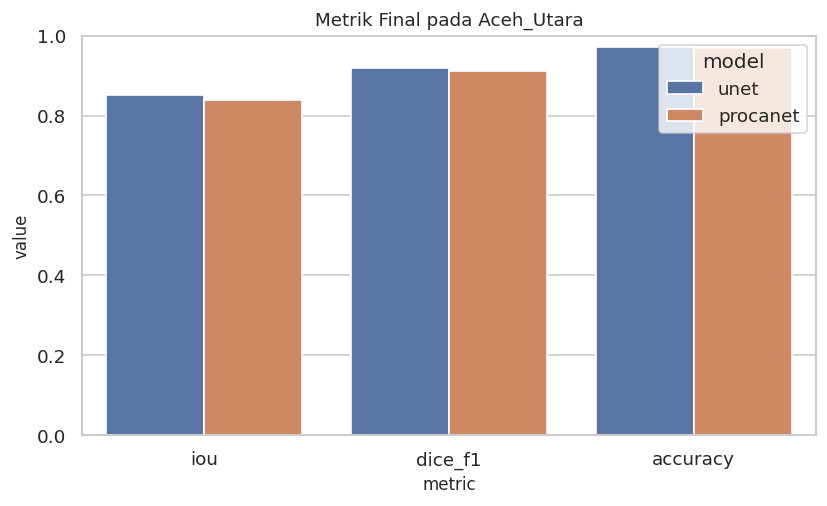

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_5_final_metrics_comparison.png')

In [13]:
final_rows = []
conf_rows = []
for model in ["unet", "procanet"]:
    csv_path = RUNS / "final" / model / "eval_test" / "metrics.csv"
    json_path = RUNS / "final" / model / "eval_test" / "metrics.json"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        row = df[df.get("region", "") == TEST_REGION].head(1)
        if row.empty:
            row = df.head(1)
        rec = row.iloc[0].to_dict() if not row.empty else {}
    elif json_path.exists():
        data = json.loads(json_path.read_text())
        rec = data.get("metrics", data)
    else:
        rec = {"status": "missing", "note": f"No metrics for {model}"}
    final_rows.append({
        "model": model,
        "region": rec.get("region", TEST_REGION),
        "loss": rec.get("loss", np.nan),
        "iou": rec.get("iou", rec.get("jaccard", np.nan)),
        "dice_f1": rec.get("dice", rec.get("f1", np.nan)),
        "accuracy": rec.get("accuracy", np.nan),
        "precision": rec.get("precision", np.nan),
        "recall": rec.get("recall", np.nan),
        "source": str((csv_path if csv_path.exists() else json_path).relative_to(ROOT)) if (csv_path.exists() or json_path.exists()) else "missing",
        "status": rec.get("status", "ok"),
    })
    conf_rows.append({
        "model": model,
        "region": rec.get("region", TEST_REGION),
        "tp": rec.get("tp", np.nan),
        "tn": rec.get("tn", np.nan),
        "fp": rec.get("fp", np.nan),
        "fn": rec.get("fn", np.nan),
        "status": rec.get("status", "ok"),
    })
final_metrics = pd.DataFrame(final_rows)
confusion = pd.DataFrame(conf_rows)
save_table(final_metrics, "4_5_final_metrics.csv")
save_table(confusion, "4_5_confusion_matrix_pixels.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = final_metrics.melt(id_vars=["model"], value_vars=[c for c in ["iou", "dice_f1", "accuracy"] if c in final_metrics], var_name="metric", value_name="value")
plot_df = plot_df[np.isfinite(plot_df["value"])]
if not plot_df.empty:
    sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title("Metrik Final pada Aceh_Utara")
else:
    ax.text(0.5, 0.5, "Final metrics unavailable", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_5_final_metrics_comparison.png")


## 4.6 Analisis Visual dan Spasial Hasil Segmentasi

Panel visual tile Aceh_Utara dan error map TP/FP/FN/TN.


saved figure: outputs/bab4/figures/4_6_segmentation_panel_aceh_utara.png


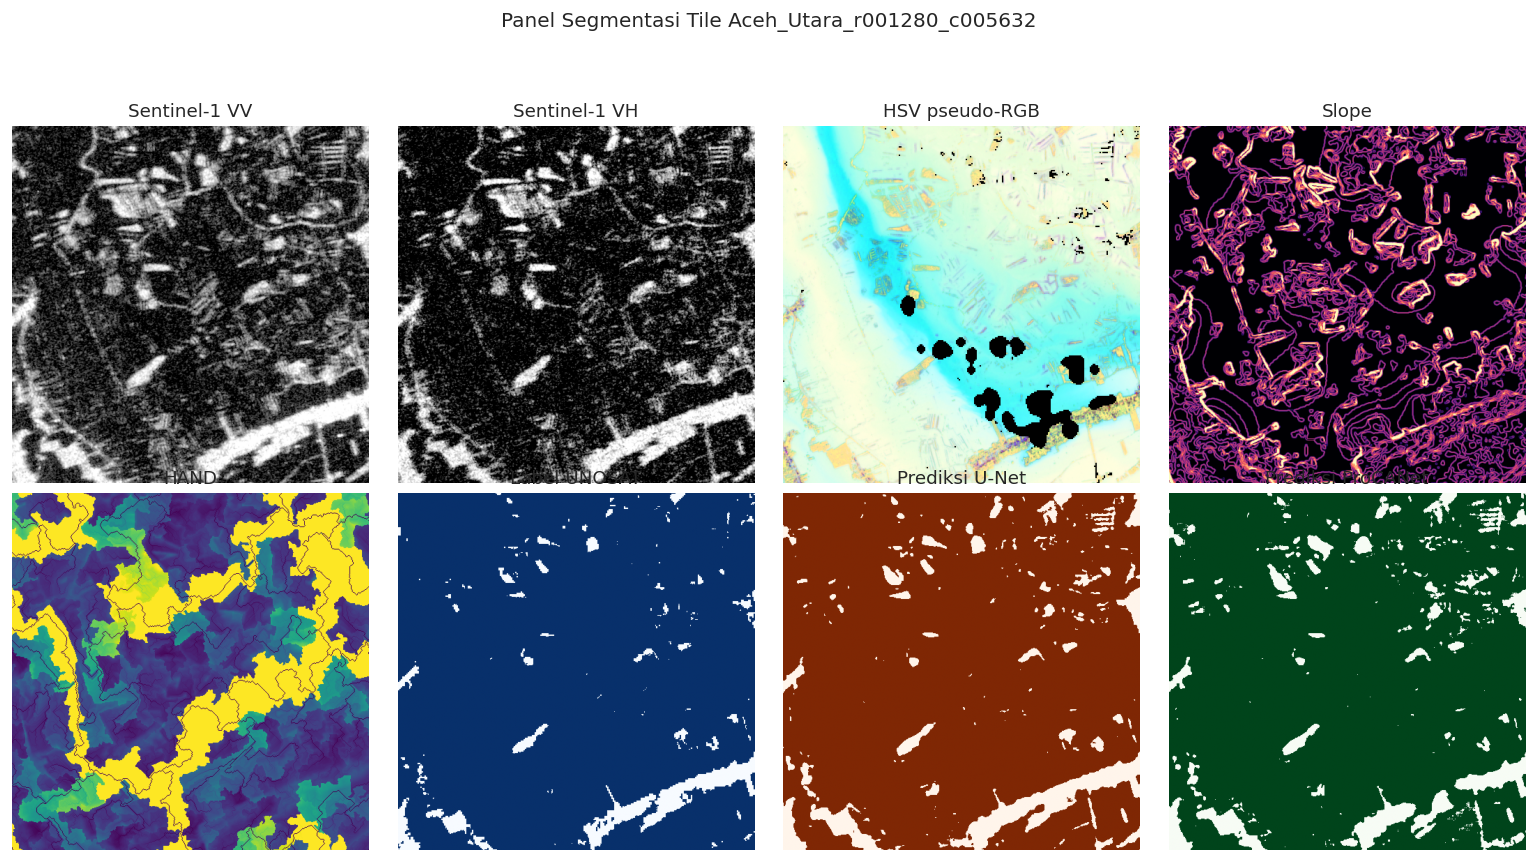

saved figure: outputs/bab4/figures/4_6_error_map_aceh_utara.png


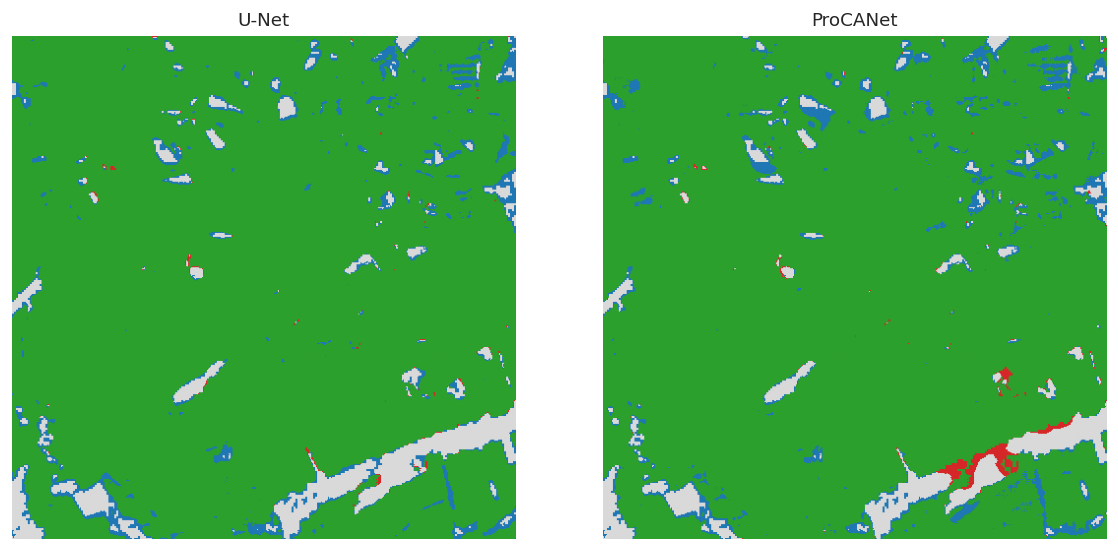

saved table: outputs/bab4/tables/4_6_error_map_tile_counts.csv (2 rows)


,model,tile,tn,tp,fp,fn,status
0,U-Net,Aceh_Utara_r001280_c005632.npz,14620,235920,392,11212,ok
1,ProCANet,Aceh_Utara_r001280_c005632.npz,13314,234926,1698,12206,ok


In [14]:
def load_prediction_array(model: str, tile_path: Path, label_shape: tuple[int, int]) -> np.ndarray | None:
    pred_npz = find_matching_prediction(model, tile_path)
    if pred_npz and pred_npz.exists():
        z = load_npz(pred_npz)
        for key in ["prediction", "pred", "mask", "y_pred"]:
            if key in z.files:
                arr = np.asarray(z[key]).squeeze()
                return (arr > 0.5).astype("uint8")
        for key in z.files:
            arr = np.asarray(z[key])
            if arr.shape[-2:] == label_shape and np.issubdtype(arr.dtype, np.number):
                return (arr.squeeze() > 0.5).astype("uint8")
    geotiff = RUNS / "final" / model / "eval_test" / "geotiff" / f"{TEST_REGION}_prediction.tif"
    if rasterio is not None and geotiff.exists():
        try:
            with rasterio.open(geotiff) as src:
                return (src.read(1) > 0).astype("uint8")
        except Exception:
            return None
    return None

vis_status_rows = []
tile_path = choose_tile(TEST_REGION)
if tile_path is None:
    vis_status_rows.append({"section": "4.6", "status": "missing_tile", "note": "No Aceh_Utara tile found"})
else:
    z = load_npz(tile_path)
    x = np.asarray(z["x"])
    y = np.asarray(z["y"]).squeeze().astype("uint8")
    valid = np.asarray(z.get("valid_mask", np.ones_like(y)[None])).squeeze() > 0
    unet_pred = load_prediction_array("unet", tile_path, y.shape)
    procanet_pred = load_prediction_array("procanet", tile_path, y.shape)
    if unet_pred is not None and unet_pred.shape != y.shape:
        unet_pred = None
        vis_status_rows.append({"section": "4.6", "status": "shape_mismatch", "note": "U-Net prediction shape differs from tile label; panel uses blank"})
    if procanet_pred is not None and procanet_pred.shape != y.shape:
        procanet_pred = None
        vis_status_rows.append({"section": "4.6", "status": "shape_mismatch", "note": "ProCANet prediction shape differs from tile label; panel uses blank"})
    unet_show = np.zeros_like(y) if unet_pred is None else unet_pred
    procanet_show = np.zeros_like(y) if procanet_pred is None else procanet_pred

    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.ravel()
    panels = [
        (normalize_image(x[0]), "Sentinel-1 VV", "gray"),
        (normalize_image(x[1]), "Sentinel-1 VH", "gray"),
        (np.dstack([normalize_image(x[4]), normalize_image(x[3]), normalize_image(x[2])]), "HSV pseudo-RGB", None),
        (normalize_image(x[5]), "Slope", "magma"),
        (normalize_image(x[6]), "HAND", "viridis"),
        (np.ma.masked_where(~valid, y), "Label UNOSAT", "Blues"),
        (np.ma.masked_where(~valid, unet_show), "Prediksi U-Net", "Oranges"),
        (np.ma.masked_where(~valid, procanet_show), "Prediksi ProCANet", "Greens"),
    ]
    for ax, (arr, title, cmap) in zip(axes, panels):
        ax.imshow(arr, cmap=cmap) if cmap else ax.imshow(arr)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"Panel Segmentasi Tile {tile_path.stem}", y=1.02)
    save_fig(fig, "4_6_segmentation_panel_aceh_utara.png")

    error_rows = []
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
    for ax, model, pred in [(axes[0], "U-Net", unet_pred), (axes[1], "ProCANet", procanet_pred)]:
        if pred is None:
            ax.text(0.5, 0.5, "prediction unavailable", ha="center", va="center")
            ax.axis("off")
            error_rows.append({"model": model, "status": "missing_prediction"})
            continue
        err = np.full(y.shape, -1, dtype="int16")
        err[(y == 0) & (pred == 0) & valid] = 0  # TN
        err[(y == 1) & (pred == 1) & valid] = 1  # TP
        err[(y == 0) & (pred == 1) & valid] = 2  # FP
        err[(y == 1) & (pred == 0) & valid] = 3  # FN
        cmap = plt.matplotlib.colors.ListedColormap(["#D9D9D9", "#2CA02C", "#D62728", "#1F77B4"])
        masked = np.ma.masked_where(err < 0, err)
        ax.imshow(masked, cmap=cmap, vmin=0, vmax=3)
        ax.set_title(model)
        ax.axis("off")
        error_rows.append({
            "model": model,
            "tile": tile_path.name,
            "tn": int((err == 0).sum()),
            "tp": int((err == 1).sum()),
            "fp": int((err == 2).sum()),
            "fn": int((err == 3).sum()),
            "status": "ok",
        })
    save_fig(fig, "4_6_error_map_aceh_utara.png")
    save_table(pd.DataFrame(error_rows), "4_6_error_map_tile_counts.csv")

if vis_status_rows:
    save_table(pd.DataFrame(vis_status_rows), "4_6_visual_status.csv")


## 4.7 Pembahasan Efektivitas U-Net vs ProCANet

Tabel sintesis trade-off berdasarkan metrik final dan confusion matrix.


In [15]:
comparison = final_metrics.merge(confusion, on=["model", "region", "status"], how="left")
for col in ["tp", "tn", "fp", "fn"]:
    if col not in comparison.columns:
        comparison[col] = np.nan
comparison["fp_rate_vs_valid"] = comparison.apply(lambda r: safe_div(r.get("fp", np.nan), np.nansum([r.get("tp", 0), r.get("tn", 0), r.get("fp", 0), r.get("fn", 0)])), axis=1)
comparison["fn_rate_vs_valid"] = comparison.apply(lambda r: safe_div(r.get("fn", np.nan), np.nansum([r.get("tp", 0), r.get("tn", 0), r.get("fp", 0), r.get("fn", 0)])), axis=1)
comparison["interpretation_note"] = comparison.apply(
    lambda r: "higher IoU/Dice indicates stronger overlap; FP/FN columns show overprediction/underprediction trade-off" if r.get("status") == "ok" else "metrics unavailable",
    axis=1,
)
save_table(comparison, "4_7_unet_vs_procanet_effectiveness_summary.csv")


saved table: outputs/bab4/tables/4_7_unet_vs_procanet_effectiveness_summary.csv (2 rows)


,model,region,loss,iou,dice_f1,accuracy,precision,recall,source,status,tp,tn,fp,fn,fp_rate_vs_valid,fn_rate_vs_valid,interpretation_note
0,unet,Aceh_Utara,0.604995,0.850992,0.919498,0.970733,NaN,NaN,runs/final/unet/eval_test/metrics.csv,ok,16863330,81075762,1227212,1725554,0.012164,0.017103,higher IoU/Dice indicates stronger overlap; FP...
1,procanet,Aceh_Utara,0.628500,0.838298,0.912037,0.968751,NaN,NaN,runs/final/procanet/eval_test/metrics.csv,ok,16344540,81394556,908418,2244344,0.009004,0.022245,higher IoU/Dice indicates stronger overlap; FP...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_7_unet_vs_procanet_effectiveness_summary.csv')

## 4.8 Ketahanan Model pada Kondisi Data Sulit

Studi kasus Sentinel-2 kosong/hampir kosong, mask air/sungai, dan konteks topografi.


saved table: outputs/bab4/tables/4_8_difficult_data_case_studies.csv (11 rows)


,region,s2_valid_pct_of_valid,water_river_pct_of_valid,flood_pct_of_valid,condition_flag,recommended_use_in_discussion
2,Aceh_Timur,53.8605,4.5989,5.6810,normal/usable,optional
0,Aceh_Besar,80.5364,2.4376,4.6434,normal/usable,optional
5,Banda_Aceh,83.8523,2.9938,6.0722,normal/usable,optional
6,Bireuen,87.9336,3.6323,5.5702,normal/usable,optional
10,Pidie_Jaya,91.5386,3.2262,5.0772,normal/usable,optional
9,Pidie,95.8625,2.7297,5.8758,normal/usable,optional
4,Agam,0.0000,0.0000,1.9329,Sentinel-2 kosong/hampir kosong,yes
7,Langsa,0.0000,10.0131,6.3725,Sentinel-2 kosong/hampir kosong; water/river m...,yes
1,Aceh_Tamiang,0.0008,5.3545,4.2698,Sentinel-2 kosong/hampir kosong,yes
8,Pasaman_Barat,0.0022,0.0000,1.1311,Sentinel-2 kosong/hampir kosong,yes


saved figure: outputs/bab4/figures/4_8_difficult_data_case_studies.png


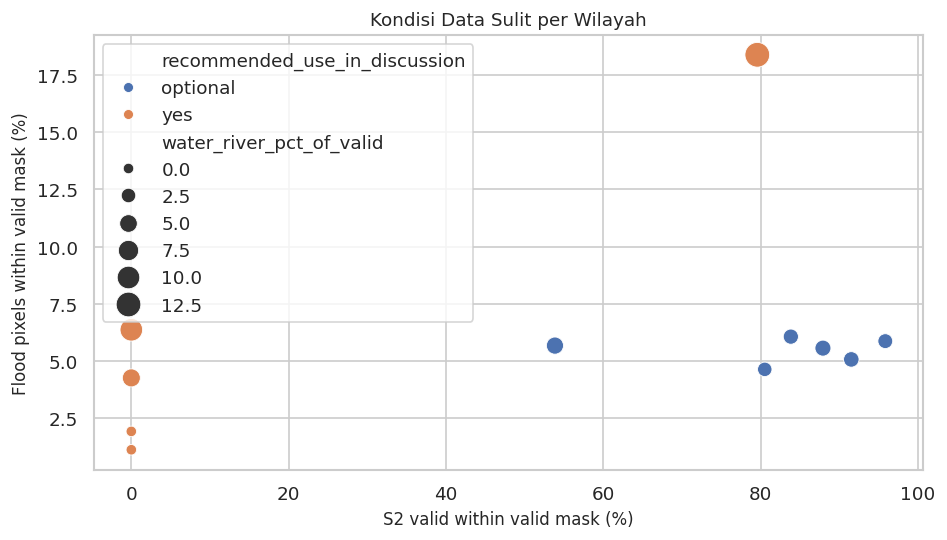

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_8_difficult_data_case_studies.png')

In [16]:
case_rows = []
for region in REGIONS:
    row = label_stats[label_stats["region"].eq(region)]
    if row.empty:
        continue
    rec = row.iloc[0].to_dict()
    condition = []
    if rec.get("s2_valid_pct_of_valid", 100) < 5:
        condition.append("Sentinel-2 kosong/hampir kosong")
    elif rec.get("s2_valid_pct_of_valid", 100) < 50:
        condition.append("Sentinel-2 valid terbatas")
    if rec.get("water_river_pct_of_valid", 0) > 10:
        condition.append("water/river mask dominan")
    if rec.get("flood_pct_of_valid", 0) < 1:
        condition.append("banjir sangat minor")
    case_rows.append({
        "region": region,
        "s2_valid_pct_of_valid": rec.get("s2_valid_pct_of_valid"),
        "water_river_pct_of_valid": rec.get("water_river_pct_of_valid"),
        "flood_pct_of_valid": rec.get("flood_pct_of_valid"),
        "condition_flag": "; ".join(condition) if condition else "normal/usable",
        "recommended_use_in_discussion": "yes" if condition else "optional",
    })
case_studies = pd.DataFrame(case_rows).sort_values(["recommended_use_in_discussion", "s2_valid_pct_of_valid"])
save_table(case_studies, "4_8_difficult_data_case_studies.csv")

fig, ax = plt.subplots(figsize=(8, 4.8))
if not case_studies.empty:
    sns.scatterplot(data=case_studies, x="s2_valid_pct_of_valid", y="flood_pct_of_valid", size="water_river_pct_of_valid", hue="recommended_use_in_discussion", ax=ax, sizes=(40, 220))
    ax.set_xlabel("S2 valid within valid mask (%)")
    ax.set_ylabel("Flood pixels within valid mask (%)")
    ax.set_title("Kondisi Data Sulit per Wilayah")
else:
    ax.text(0.5, 0.5, "No case-study data", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_8_difficult_data_case_studies.png")


## 4.9 Ringkasan Temuan Bab 4

Tabel mini untuk membantu narasi sintesis akhir BAB 4.


In [17]:
summary_rows = [
    {"subbab": "4.1", "tema": "Kualitas input multisensor", "temuan_ringkas": "SAR tersedia stabil; validitas Sentinel-2 bervariasi; DEMNAS memberi konteks topografi.", "output_pendukung": "4_1_1_preprocessing_stats.csv; 4_1_2_alignment_verification.csv"},
    {"subbab": "4.2", "tema": "Label dan class imbalance", "temuan_ringkas": "Label banjir minor dibanding non-banjir; valid mask membatasi area evaluasi.", "output_pendukung": "4_2_label_mask_tile_stats.csv"},
    {"subbab": "4.3", "tema": "Validasi spasial", "temuan_ringkas": "Split berbasis wilayah mengurangi kebocoran spasial antara training dan pengujian final.", "output_pendukung": "4_3_spatial_split_summary.csv"},
    {"subbab": "4.4", "tema": "Implementasi dan training", "temuan_ringkas": "U-Net menjadi baseline 7-channel; ProCANet memakai fusi dual-encoder/cross-attention.", "output_pendukung": "4_4_1_model_architecture_specs.csv; 4_4_3_training_curves.png"},
    {"subbab": "4.5-4.7", "tema": "Evaluasi model", "temuan_ringkas": "Perbandingan IoU, Dice, accuracy, FP, dan FN menunjukkan trade-off cakupan prediksi.", "output_pendukung": "4_5_final_metrics.csv; 4_7_unet_vs_procanet_effectiveness_summary.csv"},
    {"subbab": "4.8", "tema": "Ketahanan data sulit", "temuan_ringkas": "Kasus Sentinel-2 terbatas dan mask air/sungai perlu dibahas sebagai batasan interpretasi.", "output_pendukung": "4_8_difficult_data_case_studies.csv"},
]
chapter_summary = pd.DataFrame(summary_rows)
save_table(chapter_summary, "4_9_bab4_findings_summary.csv")


saved table: outputs/bab4/tables/4_9_bab4_findings_summary.csv (6 rows)


,subbab,tema,temuan_ringkas,output_pendukung
0,4.1,Kualitas input multisensor,SAR tersedia stabil; validitas Sentinel-2 berv...,4_1_1_preprocessing_stats.csv; 4_1_2_alignment...
1,4.2,Label dan class imbalance,Label banjir minor dibanding non-banjir; valid...,4_2_label_mask_tile_stats.csv
2,4.3,Validasi spasial,Split berbasis wilayah mengurangi kebocoran sp...,4_3_spatial_split_summary.csv
3,4.4,Implementasi dan training,U-Net menjadi baseline 7-channel; ProCANet mem...,4_4_1_model_architecture_specs.csv; 4_4_3_trai...
4,4.5-4.7,Evaluasi model,"Perbandingan IoU, Dice, accuracy, FP, dan FN m...",4_5_final_metrics.csv; 4_7_unet_vs_procanet_ef...
5,4.8,Ketahanan data sulit,Kasus Sentinel-2 terbatas dan mask air/sungai ...,4_8_difficult_data_case_studies.csv


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_9_bab4_findings_summary.csv')

## 4.1.1 Tambahan: Raw dB dan Kebijakan Clipping

Melengkapi statistik raw Sentinel-1 VV/VH, kebijakan clipping `[-30, 0]` dB, dan normalisasi `[0,1]` sesuai dokumen preprocessing.


In [18]:
def find_raw_s1(region: str) -> Path | None:
    raw_root = DATASET / "satelit raw"
    candidates = []
    variants = {region, region.replace("_", " ")}
    for folder in raw_root.glob("*"):
        folder_norm = folder.name.replace(" ", "_")
        if folder.name in variants or folder_norm == region:
            candidates.extend(sorted(folder.glob("S1_*.tif")))
    return candidates[0] if candidates else None


def sampled_band_stats(path: Path, band: int, max_size: int = 768) -> dict:
    with rasterio.open(path) as src:
        out_h = min(src.height, max_size)
        out_w = min(src.width, max_size)
        arr = src.read(band, out_shape=(out_h, out_w), masked=True)
        vals = arr.compressed() if np.ma.isMaskedArray(arr) else arr.ravel()
        stats = finite_stats(vals)
        stats.update({"height": src.height, "width": src.width, "crs": str(src.crs), "band_description": src.descriptions[band-1] or f"band_{band}"})
        return stats

raw_rows = []
for region in REGIONS:
    raw = find_raw_s1(region)
    if raw is None:
        raw_rows.append({"region": region, "status": "missing_raw_s1", "source": "dataset/satelit raw"})
        continue
    with rasterio.open(raw) as src:
        band_map = {desc.upper() if desc else f"B{i}": i for i, desc in enumerate(src.descriptions, start=1)}
    for pol in ["VV", "VH"]:
        band = band_map.get(pol)
        if band is None:
            raw_rows.append({"region": region, "polarization": pol, "status": "missing_band", "source": str(raw.relative_to(ROOT))})
            continue
        stats = sampled_band_stats(raw, band)
        raw_rows.append({
            "region": region,
            "polarization": pol,
            "source": str(raw.relative_to(ROOT)),
            "clip_low_db": -30.0,
            "clip_high_db": 0.0,
            "normalization_formula": "clip(value, -30, 0); (value + 30) / 30",
            "status": "ok",
            **stats,
        })
raw_s1_stats = pd.DataFrame(raw_rows)
save_table(raw_s1_stats, "4_1_1_raw_s1_db_clipping_stats.csv")

policy = pd.DataFrame([
    {"feature": "Sentinel-1 VV/VH", "raw_unit": "dB", "clip_range": "[-30, 0]", "normalization": "(clip(value, -30, 0) + 30) / 30", "source": "scripts/preprocessing_utils.py::normalize_db; dataset/preprocess_steps.md"},
    {"feature": "Slope", "raw_unit": "degree", "clip_range": "[0, 45] or project config", "normalization": "normalize_clip", "source": "scripts/preprocess_features.py; dataset/preprocess_steps.md"},
    {"feature": "HAND", "raw_unit": "meter", "clip_range": "[0, 50] or project config", "normalization": "normalize_clip", "source": "scripts/preprocess_features.py; dataset/preprocess_steps.md"},
    {"feature": "Sentinel-2 HSV", "raw_unit": "unitless", "clip_range": "[0, 1]", "normalization": "RGB clip then HSV transform", "source": "scripts/preprocessing_utils.py::rgb_to_hsv"},
])
save_table(policy, "4_1_1_preprocessing_policy_summary.csv")


saved table: outputs/bab4/tables/4_1_1_raw_s1_db_clipping_stats.csv (20 rows)


,region,polarization,source,clip_low_db,clip_high_db,normalization_formula,status,count,valid_pct,min,max,mean,std,p2,p98,height,width,crs,band_description
0,Aceh_Besar,VV,dataset/satelit raw/Aceh Besar/S1_Aceh_Besar_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,216368.0,36.6835,-43.410383,23.849128,-8.061625,4.345211,-17.766818,1.668314,8175.0,9662.0,EPSG:32646,VV
1,Aceh_Besar,VH,dataset/satelit raw/Aceh Besar/S1_Aceh_Besar_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,216368.0,36.6835,-49.653089,14.712382,-14.662191,4.489846,-25.216089,-5.449330,8175.0,9662.0,EPSG:32646,VH
2,Aceh_Tamiang,VV,dataset/satelit raw/Aceh Tamiang/S1_Aceh_Tamia...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,296409.0,50.2538,-48.127809,23.757377,-9.205227,5.099780,-24.185330,-0.748163,7013.0,6210.0,EPSG:32647,VV
3,Aceh_Tamiang,VH,dataset/satelit raw/Aceh Tamiang/S1_Aceh_Tamia...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,296409.0,50.2538,-50.608216,16.808048,-15.772299,5.104276,-30.166475,-7.497419,7013.0,6210.0,EPSG:32647,VH
4,Aceh_Timur,VV,dataset/satelit raw/Aceh Timur/S1_Aceh_Timur_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,311544.0,52.8198,-48.394600,24.138377,-8.658159,4.986098,-23.371167,-0.257172,12096.0,8470.0,EPSG:32647,VV
5,Aceh_Timur,VH,dataset/satelit raw/Aceh Timur/S1_Aceh_Timur_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,311544.0,52.8198,-53.376305,16.934752,-15.178341,5.149933,-29.827945,-6.954083,12096.0,8470.0,EPSG:32647,VH
6,Aceh_Utara,VV,dataset/satelit raw/Aceh Utara/S1_Aceh_Utara_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,338251.0,57.3478,-51.689931,23.243717,-10.223457,6.218301,-28.145422,-2.323612,5824.0,8101.0,EPSG:32647,VV
7,Aceh_Utara,VH,dataset/satelit raw/Aceh Utara/S1_Aceh_Utara_K...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,338251.0,57.3478,-51.506468,16.009651,-16.838493,6.194328,-35.393585,-9.258966,5824.0,8101.0,EPSG:32647,VH
8,Agam,VV,dataset/satelit raw/Agam/S1_Agam_Komposit_medi...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,307663.0,52.1618,-47.459790,27.001593,-9.291941,5.326567,-25.746416,-0.341548,4961.0,8606.0,EPSG:32747,VV
9,Agam,VH,dataset/satelit raw/Agam/S1_Agam_Komposit_medi...,-30.0,0.0,"clip(value, -30, 0); (value + 30) / 30",ok,307663.0,52.1618,-50.627960,17.367522,-15.707831,5.142516,-30.864660,-7.027421,4961.0,8606.0,EPSG:32747,VH


saved table: outputs/bab4/tables/4_1_1_preprocessing_policy_summary.csv (4 rows)


,feature,raw_unit,clip_range,normalization,source
0,Sentinel-1 VV/VH,dB,"[-30, 0]","(clip(value, -30, 0) + 30) / 30",scripts/preprocessing_utils.py::normalize_db; ...
1,Slope,degree,"[0, 45] or project config",normalize_clip,scripts/preprocess_features.py; dataset/prepro...
2,HAND,meter,"[0, 50] or project config",normalize_clip,scripts/preprocess_features.py; dataset/prepro...
3,Sentinel-2 HSV,unitless,"[0, 1]",RGB clip then HSV transform,scripts/preprocessing_utils.py::rgb_to_hsv


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_1_1_preprocessing_policy_summary.csv')

## 4.1.2 Tambahan: Verifikasi `stack_7ch.tif` dan Overlay OSM

Memastikan band `stack_7ch.tif` sejajar dengan layer individual dan membuat overlay OpenStreetMap untuk tile Aceh_Utara.


In [19]:
stack_rows = []
layer_files = ["vv_norm.tif", "vh_norm.tif", "hue.tif", "saturation.tif", "value.tif", "slope_norm.tif", "hand_norm.tif"]
for region in REGIONS:
    fdir = DATASET / "features_preprocessed" / region
    stack_path = fdir / "stack_7ch.tif"
    if not stack_path.exists():
        stack_rows.append({"region": region, "status": "missing_stack", "path": str(stack_path.relative_to(ROOT))})
        continue
    try:
        with rasterio.open(stack_path) as stack:
            stack_profile = {"width": stack.width, "height": stack.height, "crs": str(stack.crs), "transform": stack.transform}
            for idx, layer in enumerate(layer_files, start=1):
                layer_path = fdir / layer
                if not layer_path.exists():
                    stack_rows.append({"region": region, "band": idx, "layer": layer, "status": "missing_layer"})
                    continue
                with rasterio.open(layer_path) as src:
                    same_shape = (src.width == stack.width and src.height == stack.height)
                    same_crs = str(src.crs) == str(stack.crs)
                    same_transform = src.transform.almost_equals(stack.transform)
                    band_stats = finite_stats(stack.read(idx, out_shape=(min(stack.height, 512), min(stack.width, 512)), masked=True).compressed())
                    stack_rows.append({
                        "region": region,
                        "band": idx,
                        "expected_layer": layer,
                        "stack_path": str(stack_path.relative_to(ROOT)),
                        "layer_path": str(layer_path.relative_to(ROOT)),
                        "stack_shape": f"{stack.height}x{stack.width}",
                        "layer_shape": f"{src.height}x{src.width}",
                        "crs_match": same_crs,
                        "transform_match": same_transform,
                        "shape_match": same_shape,
                        "status_alignment": "Selaras" if same_shape and same_crs and same_transform else "Perlu cek",
                        "mean_sample": band_stats.get("mean"),
                        "std_sample": band_stats.get("std"),
                    })
    except Exception as exc:
        stack_rows.append({"region": region, "status": "read_error", "note": f"{type(exc).__name__}: {exc}"})
stack_verification = pd.DataFrame(stack_rows)
save_table(stack_verification, "4_1_2_stack_7ch_layer_verification.csv")


saved table: outputs/bab4/tables/4_1_2_stack_7ch_layer_verification.csv (77 rows)


,region,band,expected_layer,stack_path,layer_path,stack_shape,layer_shape,crs_match,transform_match,shape_match,status_alignment,mean_sample,std_sample
0,Aceh_Besar,1,vv_norm.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/vv_no...,8175x9662,8175x9662,True,True,True,Selaras,0.267130,0.360807
1,Aceh_Besar,2,vh_norm.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/vh_no...,8175x9662,8175x9662,True,True,True,Selaras,0.187625,0.261775
2,Aceh_Besar,3,hue.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/hue.tif,8175x9662,8175x9662,True,True,True,Selaras,0.087427,0.141853
3,Aceh_Besar,4,saturation.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/satur...,8175x9662,8175x9662,True,True,True,Selaras,0.244839,0.394406
4,Aceh_Besar,5,value.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/value...,8175x9662,8175x9662,True,True,True,Selaras,0.095636,0.160611
5,Aceh_Besar,6,slope_norm.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/slope...,8175x9662,8175x9662,True,True,True,Selaras,0.110165,0.200254
6,Aceh_Besar,7,hand_norm.tif,dataset/features_preprocessed/Aceh_Besar/stack...,dataset/features_preprocessed/Aceh_Besar/hand_...,8175x9662,8175x9662,True,True,True,Selaras,0.217297,0.367157
7,Aceh_Tamiang,1,vv_norm.tif,dataset/features_preprocessed/Aceh_Tamiang/sta...,dataset/features_preprocessed/Aceh_Tamiang/vv_...,7013x6210,7013x6210,True,True,True,Selaras,0.348195,0.366170
8,Aceh_Tamiang,2,vh_norm.tif,dataset/features_preprocessed/Aceh_Tamiang/sta...,dataset/features_preprocessed/Aceh_Tamiang/vh_...,7013x6210,7013x6210,True,True,True,Selaras,0.240155,0.263873
9,Aceh_Tamiang,3,hue.tif,dataset/features_preprocessed/Aceh_Tamiang/sta...,dataset/features_preprocessed/Aceh_Tamiang/hue...,7013x6210,7013x6210,True,True,True,Selaras,0.000000,0.000000


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_1_2_stack_7ch_layer_verification.csv')

saved figure: outputs/bab4/figures/4_1_2_osm_overlay_stack_aceh_utara.png


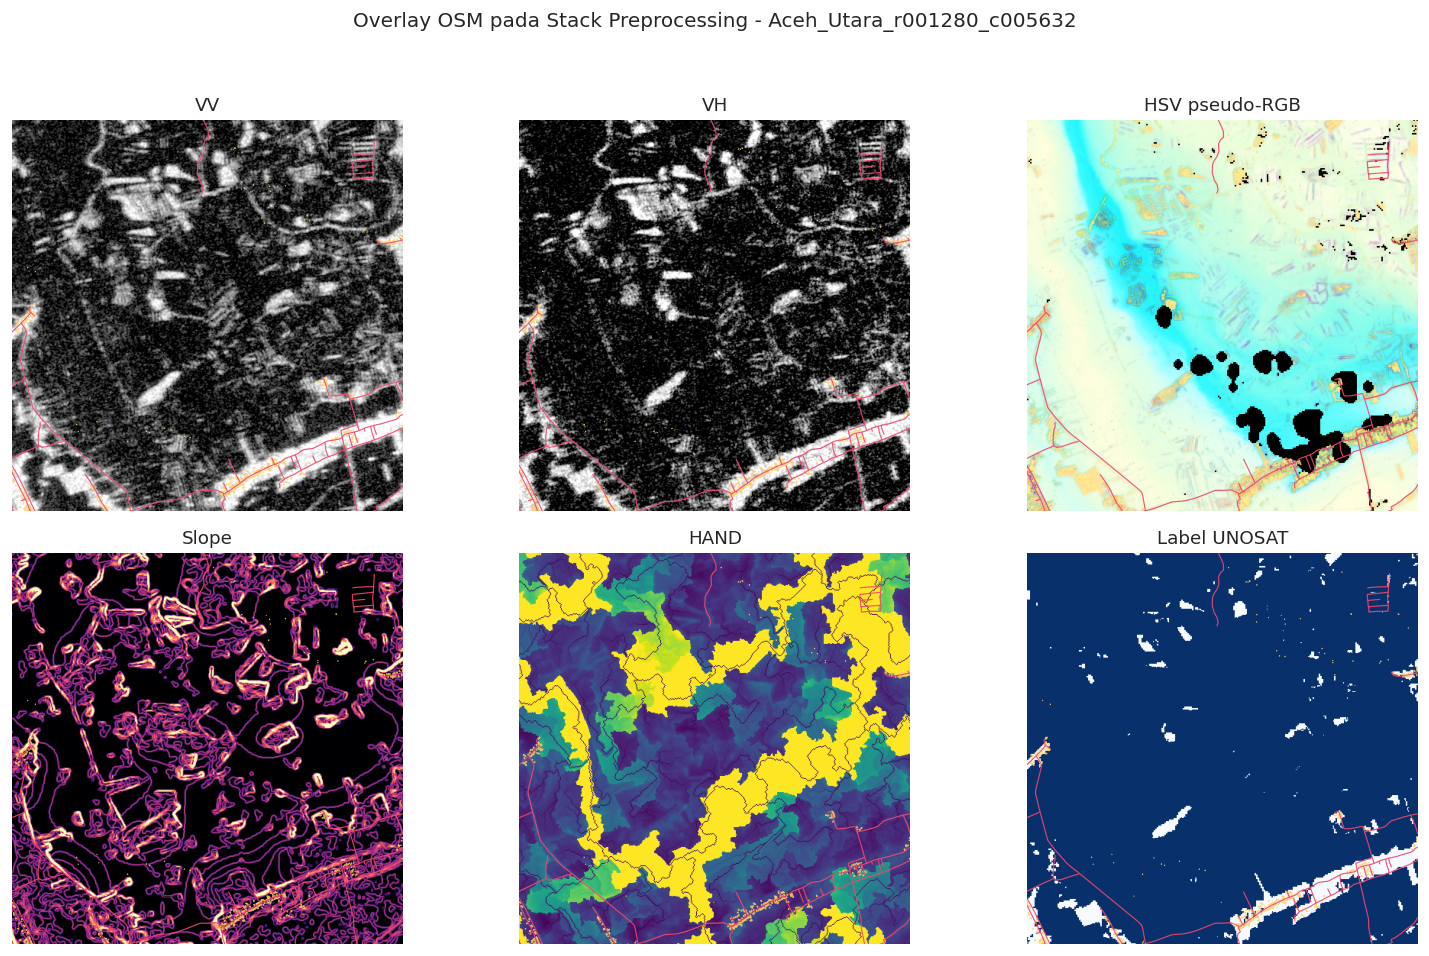

saved table: outputs/bab4/tables/4_1_2_osm_overlay_status.csv (1 rows)


,region,tile,status,features,figure
0,Aceh_Utara,Aceh_Utara_r001280_c005632.npz,ok,422,outputs/bab4/figures/4_1_2_osm_overlay_stack_a...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_1_2_osm_overlay_status.csv')

In [20]:
from rasterio.windows import Window
from rasterio.plot import plotting_extent
from pyproj import Transformer
import geopandas as gpd
import osmnx as ox


def read_stack_window_for_tile(tile_path: Path, region: str):
    r, c = parse_tile_rc(tile_path)
    if r is None or c is None:
        r = c = 0
    stack_path = DATASET / "features_preprocessed" / region / "stack_7ch.tif"
    label_path = DATASET / "labels_unosat_rasterized" / region / "label_flood_binary.tif"
    with rasterio.open(stack_path) as src:
        window = Window(c, r, min(512, src.width - c), min(512, src.height - r))
        arr = src.read(window=window, boundless=True, fill_value=0)
        transform = src.window_transform(window)
        extent = plotting_extent(arr[0], transform)
        crs = src.crs
        bounds = rasterio.windows.bounds(window, src.transform)
    label = None
    if label_path.exists():
        with rasterio.open(label_path) as lab:
            label = lab.read(1, window=window, boundless=True, fill_value=0)
    return arr, label, extent, bounds, crs


def fetch_osm_features(bounds_projected, crs):
    left, bottom, right, top = bounds_projected
    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    west, south = transformer.transform(left, bottom)
    east, north = transformer.transform(right, top)
    bbox = (west, south, east, north)
    tags = {"highway": True, "building": True, "waterway": True, "natural": ["water"], "landuse": ["residential", "industrial", "commercial"]}
    try:
        gdf = ox.features_from_bbox(bbox, tags)
        if gdf.empty:
            return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326"), "empty"
        return gdf.to_crs(crs), "ok"
    except Exception as exc:
        return gpd.GeoDataFrame(geometry=[], crs=crs), f"fetch_error: {type(exc).__name__}: {exc}"

osm_rows = []
tile_path = choose_tile(TEST_REGION)
if tile_path is None:
    osm_rows.append({"region": TEST_REGION, "status": "missing_tile"})
else:
    try:
        arr, label, extent, bounds, crs = read_stack_window_for_tile(tile_path, TEST_REGION)
        osm_gdf, osm_status = fetch_osm_features(bounds, crs)
        backgrounds = [
            (normalize_image(arr[0]), "VV", "gray"),
            (normalize_image(arr[1]), "VH", "gray"),
            (np.dstack([normalize_image(arr[4]), normalize_image(arr[3]), normalize_image(arr[2])]), "HSV pseudo-RGB", None),
            (normalize_image(arr[5]), "Slope", "magma"),
            (normalize_image(arr[6]), "HAND", "viridis"),
            (normalize_image(label) if label is not None else np.zeros(arr.shape[1:]), "Label UNOSAT", "Blues"),
        ]
        fig, axes = plt.subplots(2, 3, figsize=(13, 8))
        axes = axes.ravel()
        for ax, (bg, title, cmap) in zip(axes, backgrounds):
            ax.imshow(bg, extent=extent, origin="upper", cmap=cmap) if cmap else ax.imshow(bg, extent=extent, origin="upper")
            if not osm_gdf.empty:
                line_like = osm_gdf[osm_gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])]
                poly_like = osm_gdf[osm_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
                if not poly_like.empty:
                    poly_like.boundary.plot(ax=ax, color="#FFD166", linewidth=0.6, alpha=0.8)
                if not line_like.empty:
                    line_like.plot(ax=ax, color="#EF476F", linewidth=0.7, alpha=0.9)
            ax.set_title(title)
            ax.set_xlim(extent[0], extent[1])
            ax.set_ylim(extent[2], extent[3])
            ax.axis("off")
        fig.suptitle(f"Overlay OSM pada Stack Preprocessing - {tile_path.stem}", y=0.99)
        save_fig(fig, "4_1_2_osm_overlay_stack_aceh_utara.png")
        osm_rows.append({"region": TEST_REGION, "tile": tile_path.name, "status": osm_status, "features": len(osm_gdf), "figure": "outputs/bab4/figures/4_1_2_osm_overlay_stack_aceh_utara.png"})
    except Exception as exc:
        osm_rows.append({"region": TEST_REGION, "status": "render_error", "note": f"{type(exc).__name__}: {exc}"})
osm_status_table = pd.DataFrame(osm_rows)
save_table(osm_status_table, "4_1_2_osm_overlay_status.csv")


## 4.3 Tambahan: Tabel 5-Fold Spatial Cross-Validation

Membuat tabel fold eksplisit sesuai rancangan validasi spasial pada TODO.


In [21]:
fold_defs = [
    (0, ["Pidie", "Pidie_Jaya"]),
    (1, ["Aceh_Besar", "Banda_Aceh"]),
    (2, ["Aceh_Tamiang", "Aceh_Timur"]),
    (3, ["Bireuen", "Langsa"]),
    (4, ["Agam", "Pasaman_Barat"]),
]
all_cv_regions = sorted({r for _, regs in fold_defs for r in regs})
fold_rows = []
for fold, val_regions in fold_defs:
    train_regions = [r for r in all_cv_regions if r not in val_regions]
    fold_rows.append({
        "fold": fold,
        "validation_regions": ", ".join(val_regions),
        "training_regions": ", ".join(train_regions),
        "held_out_final_test": TEST_REGION,
        "purpose": "hyperparameter tuning and training stability",
        "leakage_control": "region-level split; final test region excluded from CV",
    })
five_fold_cv = pd.DataFrame(fold_rows)
save_table(five_fold_cv, "4_3_five_fold_spatial_cv.csv")


saved table: outputs/bab4/tables/4_3_five_fold_spatial_cv.csv (5 rows)


,fold,validation_regions,training_regions,held_out_final_test,purpose,leakage_control
0,0,"Pidie, Pidie_Jaya","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",Aceh_Utara,hyperparameter tuning and training stability,region-level split; final test region excluded...
1,1,"Aceh_Besar, Banda_Aceh","Aceh_Tamiang, Aceh_Timur, Agam, Bireuen, Langs...",Aceh_Utara,hyperparameter tuning and training stability,region-level split; final test region excluded...
2,2,"Aceh_Tamiang, Aceh_Timur","Aceh_Besar, Agam, Banda_Aceh, Bireuen, Langsa,...",Aceh_Utara,hyperparameter tuning and training stability,region-level split; final test region excluded...
3,3,"Bireuen, Langsa","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",Aceh_Utara,hyperparameter tuning and training stability,region-level split; final test region excluded...
4,4,"Agam, Pasaman_Barat","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Banda_Ac...",Aceh_Utara,hyperparameter tuning and training stability,region-level split; final test region excluded...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_3_five_fold_spatial_cv.csv')

## 4.4.1 Tambahan: Verifikasi Forward Pass Aktual

Menjalankan forward pass dummy untuk memastikan kontrak input/output U-Net dan ProCANet.


In [22]:
forward_rows = []
try:
    import torch
    from training.models import UNet, ProCANet
    torch.set_grad_enabled(False)
    device = torch.device("cpu")
    configs = [
        ("U-Net", UNet(in_channels=7, out_channels=1, base_channels=32).to(device).eval(), (torch.zeros(1, 7, 128, 128),), "Batch x 7 x H x W"),
        ("ProCANet", ProCANet(encoder1_channels=7, encoder2_channels=2, out_channels=1, base_channels=32).to(device).eval(), ({"encoder1": torch.zeros(1, 7, 128, 128), "encoder2": torch.zeros(1, 2, 128, 128)},), "Encoder1 Batch x 7 x H x W; Encoder2 Batch x 2 x H x W"),
    ]
    for model_name, model, inputs, input_contract in configs:
        try:
            out = model(*inputs)
            forward_rows.append({
                "model": model_name,
                "input_contract": input_contract,
                "input_shapes": "; ".join(str({k: tuple(v.shape) for k, v in x.items()}) if isinstance(x, dict) else str(tuple(x.shape)) for x in inputs),
                "output_shape": str(tuple(out.shape)),
                "expected_output": "Batch x 1 x H x W",
                "status": "ok" if tuple(out.shape) == (1, 1, 128, 128) else "shape_mismatch",
            })
        except Exception as exc:
            forward_rows.append({"model": model_name, "input_contract": input_contract, "status": "forward_error", "note": f"{type(exc).__name__}: {exc}"})
except Exception as exc:
    forward_rows.append({"model": "all", "status": "import_error", "note": f"{type(exc).__name__}: {exc}"})
forward_pass = pd.DataFrame(forward_rows)
save_table(forward_pass, "4_4_1_forward_pass_verification.csv")


saved table: outputs/bab4/tables/4_4_1_forward_pass_verification.csv (2 rows)


,model,input_contract,input_shapes,output_shape,expected_output,status
0,U-Net,Batch x 7 x H x W,"(1, 7, 128, 128)","(1, 1, 128, 128)",Batch x 1 x H x W,ok
1,ProCANet,Encoder1 Batch x 7 x H x W; Encoder2 Batch x 2...,"{'encoder1': (1, 7, 128, 128), 'encoder2': (1,...","(1, 1, 128, 128)",Batch x 1 x H x W,ok


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_1_forward_pass_verification.csv')

## 4.4.3 Tambahan: Scheduler, Early Stopping, dan Best Checkpoint

Meringkas kebijakan training yang dipakai script pelatihan.


In [23]:
policy_rows = []
script_path = ROOT / "scripts" / "train_segmentation.py"
train_text = script_path.read_text() if script_path.exists() else ""
policy_rows.extend([
    {"component": "optimizer", "implementation": "AdamW", "evidence": "torch.optim.AdamW in scripts/train_segmentation.py", "status": "ok" if "AdamW" in train_text else "missing"},
    {"component": "scheduler", "implementation": "ReduceLROnPlateau when --lr-scheduler reduce-on-plateau", "evidence": "--lr-scheduler default reduce-on-plateau", "status": "ok" if "ReduceLROnPlateau" in train_text or "reduce-on-plateau" in train_text else "missing"},
    {"component": "early_stopping", "implementation": "EarlyStopping with patience/min_delta", "evidence": "training.train::EarlyStopping", "status": "ok" if "EarlyStopping" in train_text else "missing"},
    {"component": "best_checkpoint", "implementation": "best.pt saved when validation IoU improves", "evidence": "save_checkpoint_if_best; best_val_iou", "status": "ok" if "best_val_iou" in train_text and "save_checkpoint_if_best" in train_text else "missing"},
    {"component": "selection_metric", "implementation": "validation IoU", "evidence": "best_val_iou", "status": "ok" if "val_iou" in train_text else "missing"},
])
training_policy = pd.DataFrame(policy_rows)
save_table(training_policy, "4_4_3_training_policy_summary.csv")


saved table: outputs/bab4/tables/4_4_3_training_policy_summary.csv (5 rows)


,component,implementation,evidence,status
0,optimizer,AdamW,torch.optim.AdamW in scripts/train_segmentatio...,ok
1,scheduler,ReduceLROnPlateau when --lr-scheduler reduce-o...,--lr-scheduler default reduce-on-plateau,ok
2,early_stopping,EarlyStopping with patience/min_delta,training.train::EarlyStopping,ok
3,best_checkpoint,best.pt saved when validation IoU improves,save_checkpoint_if_best; best_val_iou,ok
4,selection_metric,validation IoU,best_val_iou,ok


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_3_training_policy_summary.csv')

## 4.7-4.9 Tambahan: Narasi Siap Pakai dan Coverage Matrix

Menyediakan tabel interpretasi/narasi untuk pembahasan serta matriks cakupan line 34-573.


In [24]:
source_layer_rows = [
    {"layer_todo": "FloodExtent", "role": "positive flood label", "notebook_artifact": "4_2_label_mask_tile_stats.csv", "status": "covered via rasterized label_flood_binary and tile y"},
    {"layer_todo": "AnalysisExtent", "role": "valid evaluation area", "notebook_artifact": "4_2_label_mask_tile_stats.csv", "status": "covered via valid_mask"},
    {"layer_todo": "WaterExtent", "role": "permanent water exclusion/context", "notebook_artifact": "4_2_label_mask_tile_stats.csv", "status": "covered via water_river_mask"},
    {"layer_todo": "River", "role": "river mask exclusion/context", "notebook_artifact": "4_2_label_mask_tile_stats.csv", "status": "covered via water_river_mask"},
]
save_table(pd.DataFrame(source_layer_rows), "4_2_unosat_source_layer_mapping.csv")

narrative_rows = [
    {"subbab": "4.1", "narasi_siap_pakai": "Preprocessing menyatukan Sentinel-1, Sentinel-2 HSV, Slope, dan HAND ke grid Sentinel-1; statistik dan verifikasi stack menunjukkan input layak dipakai sebagai tensor multisensor."},
    {"subbab": "4.2", "narasi_siap_pakai": "Label positif berasal dari FloodExtent, sedangkan AnalysisExtent membatasi area valid dan WaterExtent/River dipakai sebagai konteks/mask air permanen."},
    {"subbab": "4.3", "narasi_siap_pakai": "Validasi berbasis wilayah memisahkan area tuning dari Aceh_Utara sebagai uji final sehingga evaluasi lebih tahan terhadap kebocoran spasial."},
    {"subbab": "4.4", "narasi_siap_pakai": "U-Net dan ProCANet lolos kontrak forward pass; training memakai AdamW, scheduler ReduceLROnPlateau, early stopping, dan checkpoint terbaik berbasis validation IoU."},
    {"subbab": "4.5-4.7", "narasi_siap_pakai": "Perbandingan akhir perlu dibaca sebagai trade-off: IoU/Dice mengukur overlap, sedangkan FP/FN menunjukkan kecenderungan overprediction atau underprediction."},
    {"subbab": "4.8", "narasi_siap_pakai": "Wilayah dengan Sentinel-2 terbatas, water/river mask besar, atau label banjir kecil menjadi studi kasus ketahanan data."},
    {"subbab": "4.9", "narasi_siap_pakai": "Temuan BAB 4 menjadi dasar BAB 5: kualitas input, validitas label, konfigurasi model, dan trade-off evaluasi akhir."},
]
save_table(pd.DataFrame(narrative_rows), "4_7_4_9_discussion_narrative_snippets.csv")

forward_ok = False
try:
    forward_ok = (forward_pass["status"] == "ok").all()
except Exception:
    forward_ok = False
osm_ok = (FIG_DIR / "4_1_2_osm_overlay_stack_aceh_utara.png").exists()

coverage_items = [
    ("4.1.1", "raw Sentinel-1 dB, clipping [-30,0], normalization [0,1]", "4_1_1_raw_s1_db_clipping_stats.csv", True),
    ("4.1.1", "normalized VV/VH/HSV/Slope/HAND stats and S2 valid mask", "4_1_1_preprocessing_stats.csv", True),
    ("4.1.2", "raster metadata/alignment", "4_1_2_alignment_verification.csv", True),
    ("4.1.2", "stack_7ch band verification", "4_1_2_stack_7ch_layer_verification.csv", True),
    ("4.1.2", "OSM overlay against stack layers", "4_1_2_osm_overlay_stack_aceh_utara.png", osm_ok),
    ("4.2", "UNOSAT source layers and label/mask stats", "4_2_unosat_source_layer_mapping.csv; 4_2_label_mask_tile_stats.csv", True),
    ("4.3", "5-fold spatial cross-validation", "4_3_five_fold_spatial_cv.csv", True),
    ("4.4.1", "architecture and forward pass", "4_4_1_model_architecture_specs.csv; 4_4_1_forward_pass_verification.csv", forward_ok),
    ("4.4.2", "hyperparameter grid search", "4_4_2_hyperparameter_tuning_summary.csv", True),
    ("4.4.3", "training curves and training policy", "4_4_3_training_curves.png; 4_4_3_training_policy_summary.csv", True),
    ("4.5", "final metrics and confusion matrix", "4_5_final_metrics.csv; 4_5_confusion_matrix_pixels.csv", True),
    ("4.6", "prediction panel and error map", "4_6_segmentation_panel_aceh_utara.png; 4_6_error_map_aceh_utara.png", True),
    ("4.7", "U-Net vs ProCANet discussion summary", "4_7_unet_vs_procanet_effectiveness_summary.csv", True),
    ("4.8", "difficult data case studies", "4_8_difficult_data_case_studies.csv", True),
    ("4.9", "BAB 4 findings and transition narrative", "4_9_bab4_findings_summary.csv; 4_7_4_9_discussion_narrative_snippets.csv", True),
]
coverage = pd.DataFrame([{"subbab": s, "todo_line_34_573_requirement": req, "artifact": art, "covered": bool(cov)} for s, req, art, cov in coverage_items])
save_table(coverage, "bab4_line_34_573_coverage_matrix.csv")
missing_coverage = coverage[~coverage["covered"]]
if missing_coverage.empty:
    print("All line 34-573 coverage items are marked covered.")
else:
    print("Coverage gaps remain:")
    display(missing_coverage)


saved table: outputs/bab4/tables/4_2_unosat_source_layer_mapping.csv (4 rows)


,layer_todo,role,notebook_artifact,status
0,FloodExtent,positive flood label,4_2_label_mask_tile_stats.csv,covered via rasterized label_flood_binary and ...
1,AnalysisExtent,valid evaluation area,4_2_label_mask_tile_stats.csv,covered via valid_mask
2,WaterExtent,permanent water exclusion/context,4_2_label_mask_tile_stats.csv,covered via water_river_mask
3,River,river mask exclusion/context,4_2_label_mask_tile_stats.csv,covered via water_river_mask


saved table: outputs/bab4/tables/4_7_4_9_discussion_narrative_snippets.csv (7 rows)


,subbab,narasi_siap_pakai
0,4.1,"Preprocessing menyatukan Sentinel-1, Sentinel-..."
1,4.2,"Label positif berasal dari FloodExtent, sedang..."
2,4.3,Validasi berbasis wilayah memisahkan area tuni...
3,4.4,U-Net dan ProCANet lolos kontrak forward pass;...
4,4.5-4.7,Perbandingan akhir perlu dibaca sebagai trade-...
5,4.8,"Wilayah dengan Sentinel-2 terbatas, water/rive..."
6,4.9,Temuan BAB 4 menjadi dasar BAB 5: kualitas inp...


saved table: outputs/bab4/tables/bab4_line_34_573_coverage_matrix.csv (15 rows)


,subbab,todo_line_34_573_requirement,artifact,covered
0,4.1.1,"raw Sentinel-1 dB, clipping [-30,0], normaliza...",4_1_1_raw_s1_db_clipping_stats.csv,True
1,4.1.1,normalized VV/VH/HSV/Slope/HAND stats and S2 v...,4_1_1_preprocessing_stats.csv,True
2,4.1.2,raster metadata/alignment,4_1_2_alignment_verification.csv,True
3,4.1.2,stack_7ch band verification,4_1_2_stack_7ch_layer_verification.csv,True
4,4.1.2,OSM overlay against stack layers,4_1_2_osm_overlay_stack_aceh_utara.png,True
5,4.2,UNOSAT source layers and label/mask stats,4_2_unosat_source_layer_mapping.csv; 4_2_label...,True
6,4.3,5-fold spatial cross-validation,4_3_five_fold_spatial_cv.csv,True
7,4.4.1,architecture and forward pass,4_4_1_model_architecture_specs.csv; 4_4_1_forw...,True
8,4.4.2,hyperparameter grid search,4_4_2_hyperparameter_tuning_summary.csv,True
9,4.4.3,training curves and training policy,4_4_3_training_curves.png; 4_4_3_training_poli...,True


All line 34-573 coverage items are marked covered.


## Checklist Output

Memverifikasi artefak wajib, sangat disarankan, dan opsional yang dibuat notebook.


In [25]:
expected = [
    ("wajib", "4.1.1", TABLE_DIR / "4_1_1_preprocessing_stats.csv"),
    ("wajib", "4.1.1", TABLE_DIR / "4_1_1_s2_valid_mask_by_region.csv"),
    ("wajib", "4.1.1", FIG_DIR / "4_1_1_channel_example_aceh_utara.png"),
    ("wajib", "4.1.2", TABLE_DIR / "4_1_2_alignment_verification.csv"),
    ("wajib", "4.2", TABLE_DIR / "4_2_label_mask_tile_stats.csv"),
    ("wajib", "4.2", TABLE_DIR / "4_2_tile_distribution_by_split_region.csv"),
    ("wajib", "4.3", TABLE_DIR / "4_3_spatial_split_summary.csv"),
    ("wajib", "4.4.1", TABLE_DIR / "4_4_1_model_architecture_specs.csv"),
    ("wajib", "4.4.2", TABLE_DIR / "4_4_2_hyperparameter_tuning_summary.csv"),
    ("wajib", "4.4.3", TABLE_DIR / "4_4_3_training_curve_points.csv"),
    ("wajib", "4.5", TABLE_DIR / "4_5_final_metrics.csv"),
    ("wajib", "4.5", TABLE_DIR / "4_5_confusion_matrix_pixels.csv"),
    ("wajib", "4.6", FIG_DIR / "4_6_segmentation_panel_aceh_utara.png"),
    ("sangat_disarankan", "4.6", FIG_DIR / "4_6_error_map_aceh_utara.png"),
    ("sangat_disarankan", "4.7", TABLE_DIR / "4_7_unet_vs_procanet_effectiveness_summary.csv"),
    ("sangat_disarankan", "4.8", TABLE_DIR / "4_8_difficult_data_case_studies.csv"),
    ("opsional", "4.9", TABLE_DIR / "4_9_bab4_findings_summary.csv"),
]
checklist = pd.DataFrame([
    {"priority": prio, "subbab": subbab, "artifact": str(path.relative_to(ROOT)), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
    for prio, subbab, path in expected
])
save_table(checklist, "bab4_output_checklist.csv")
missing = checklist[~checklist["exists"]]
if not missing.empty:
    print("Missing expected artifacts:")
    display(missing)
else:
    print("All expected BAB 4 artifacts created.")


saved table: outputs/bab4/tables/bab4_output_checklist.csv (17 rows)


,priority,subbab,artifact,exists,size_bytes
0,wajib,4.1.1,outputs/bab4/tables/4_1_1_preprocessing_stats.csv,True,8929
1,wajib,4.1.1,outputs/bab4/tables/4_1_1_s2_valid_mask_by_reg...,True,393
2,wajib,4.1.1,outputs/bab4/figures/4_1_1_channel_example_ace...,True,6190022
3,wajib,4.1.2,outputs/bab4/tables/4_1_2_alignment_verificati...,True,223
4,wajib,4.2,outputs/bab4/tables/4_2_label_mask_tile_stats.csv,True,1260
5,wajib,4.2,outputs/bab4/tables/4_2_tile_distribution_by_s...,True,1262
6,wajib,4.3,outputs/bab4/tables/4_3_spatial_split_summary.csv,True,1060
7,wajib,4.4.1,outputs/bab4/tables/4_4_1_model_architecture_s...,True,516
8,wajib,4.4.2,outputs/bab4/tables/4_4_2_hyperparameter_tunin...,True,10291
9,wajib,4.4.3,outputs/bab4/tables/4_4_3_training_curve_point...,True,446070


All expected BAB 4 artifacts created.
